# Benchmarking

In [2]:
from qiskit import QuantumCircuit
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.visualization import plot_histogram 
import typing
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit_aer import Aer
from qiskit import transpile
from qiskit_aer.primitives import Sampler
from qiskit.primitives.backend_sampler import BackendSampler
from qiskit.quantum_info import Statevector
from qiskit.circuit import Instruction
from matplotlib import pyplot as plt
from qiskit.quantum_info import state_fidelity, DensityMatrix

from qiskit.quantum_info import Pauli
from qiskit_aer.noise import pauli_error 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from lmfit import Model
from pandas import DataFrame


In [4]:
no_noise = NoiseModel()

In [5]:
def steane_enc_8(amp_0: float, amp_1: float, is_ideal: bool):


    if is_ideal == True:
        steane_enc_block = QuantumCircuit(8, 8, name="steane_block")
    else:
        steane_enc_block = QuantumCircuit(8, name="steane_block_noise")


    steane_enc_block.h(0)
    steane_enc_block.h(4)
    steane_enc_block.h(6)

    #steane_enc_block.initialize([amp_0, amp_1], 6)
    steane_enc_block.initialize([amp_0, amp_1], 6)

    steane_enc_block.barrier()

    steane_enc_block.cx(0, 1)
    steane_enc_block.cx(4, 5)
    steane_enc_block.cx(6, 3)

    steane_enc_block.cx(4,2)
    steane_enc_block.cx(6,5)

    steane_enc_block.cx(0,3)
    steane_enc_block.cx(4,1)

    steane_enc_block.cx(3,2)

    steane_enc_block.cx(1,7)
    steane_enc_block.cx(3,7)
    steane_enc_block.cx(5,7)

    steane_enc_block.barrier()

    for i in range(0, 8):
        steane_enc_block.h(i)
        #steane_enc_block.measure(i,0)
    steane_enc_block.barrier()
    # steane_enc_block.measure(7,0)


    #print(steane_enc_block)

    return steane_enc_block

In [6]:
def steane_enc_7(amp_0: float, amp_1: float, is_ideal: bool):


    if is_ideal == True:
        steane_enc_block = QuantumCircuit(7, 7, name="steane_block")
    else:
        steane_enc_block = QuantumCircuit(7, name="steane_block_noise")

    for i in range(1,4):
        steane_enc_block.h(i)
    
    steane_enc_block.h(6)
    steane_enc_block.initialize([amp_0, amp_1], 6)

    steane_enc_block.barrier()

    steane_enc_block.cx(1,0)
    steane_enc_block.cx(2,4)
    steane_enc_block.cx(6,5)

    steane_enc_block.cx(2,0)
    steane_enc_block.cx(3,5)
    steane_enc_block.cx(6,4)
    steane_enc_block.cx(2,6)
    steane_enc_block.cx(3,4)
    steane_enc_block.cx(1,5)
    steane_enc_block.cx(1,6)
    steane_enc_block.cx(3,0)
    
    steane_enc_block.barrier()

    # switch to measuring in other basis
    for i in range(0, 7):
        steane_enc_block.h(i)

    #print(steane_enc_block)
    return steane_enc_block



In [7]:
def create_h_block(num: int, is_ideal: bool):
    if (is_ideal == 1):
        h_block = QuantumCircuit(num, num, name="h_block")
    else:
        h_block = QuantumCircuit(num, name="h_block_noise")

    for i in range(0, num):
        h_block.h(i)

    # convert to instruction
    h_block_instr = h_block.to_instruction()
    return h_block_instr

In [8]:
# applies cz to n qubits
def create_cz_block(num: int, is_ideal: bool):
    if (is_ideal == 1):
        cz_block = QuantumCircuit(num*2, num*2, name="cz_block")
    else:
        cz_block = QuantumCircuit(num*2, name="cz_block_noise")
    
    for i in range(0, num):
        cz_block.cz(i, i + num)
        print(num)

    # convert to instruction
    cz_block_instr = cz_block.to_instruction()
    return cz_block_instr

In [9]:
# applies identity 
def create_id_block(num: int, is_ideal: bool):

    if (is_ideal == 1):
        id_block = QuantumCircuit(num, num, name = "id_block")
    else:
        id_block = QuantumCircuit(num, name = "id_block")
    

    for i in range(0, num):
        id_block.id(i)

    id_block_instr = id_block.to_instruction()
    return id_block_instr

In [10]:
# applies x 
def create_x_block(num: int, is_ideal: bool):
    if (is_ideal == 1):
        x_block = QuantumCircuit(num, num, name = "x_block")
    else:
        x_block = QuantumCircuit(num, name = "x_block")
    

    for i in range(0, num):
        x_block.x(i)

    x_block_instr = x_block.to_instruction()
    return x_block_instr

In [11]:
def prepare_state(qc_prep: QuantumCircuit, encode_block: Instruction, log_block: Instruction, num: int, is_ideal: bool):

    if (is_ideal == 1):
        qc_prep.append(create_id_block(num, is_ideal), range(0,num), range(0,num))
        qc_prep.append(encode_block, range(0,num), range(0,num))
        qc_prep.append(create_id_block(num, is_ideal), range(0,num), range(0,num))
        qc_prep.append(log_block,range(0,num), range(0,num))
        qc_prep.draw('mpl')
    else:
        qc_prep.append(create_id_block(num, is_ideal), range(0,num))
        qc_prep.append(encode_block, range(0,num))
        qc_prep.append(create_id_block(num, is_ideal), range(0,num))
        qc_prep.append(log_block,range(0,num))
        qc_prep.draw('mpl')

In [12]:

theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0_theta = np.cos(theta/2)
amp_1_theta = np.sin(theta/2)

print(Statevector([amp_0_theta, amp_1_theta]))

steane_intr_theta_ideal = steane_enc_8(amp_0_theta, amp_1_theta, True).to_instruction()
steane_intr_theta_ideal_7 = steane_enc_7(amp_0_theta, amp_1_theta, True).to_instruction()

steane_intr_theta_n = steane_enc_8(amp_0_theta, amp_1_theta, False).to_instruction()
steane_intr_theta_n_7 = steane_enc_7(amp_0_theta, amp_1_theta, False).to_instruction()

Statevector([0.94502682+0.j, 0.32699283+0.j],
            dims=(2,))


In [13]:
print(steane_enc_7(amp_0_theta, amp_1_theta, False))

                                          ░ ┌───┐┌───┐                         »
q_0: ─────────────────────────────────────░─┤ X ├┤ X ├─────────────────────────»
     ┌───┐                                ░ └─┬─┘└─┬─┘                         »
q_1: ┤ H ├────────────────────────────────░───■────┼───────────────────■────■──»
     ├───┤                                ░        │                   │    │  »
q_2: ┤ H ├────────────────────────────────░───■────■─────────■─────────┼────┼──»
     ├───┤                                ░   │              │         │    │  »
q_3: ┤ H ├────────────────────────────────░───┼────■─────────┼────■────┼────┼──»
     └───┘                                ░ ┌─┴─┐  │  ┌───┐  │  ┌─┴─┐  │    │  »
q_4: ─────────────────────────────────────░─┤ X ├──┼──┤ X ├──┼──┤ X ├──┼────┼──»
                                          ░ ├───┤┌─┴─┐└─┬─┘  │  └───┘┌─┴─┐  │  »
q_5: ─────────────────────────────────────░─┤ X ├┤ X ├──┼────┼───────┤ X ├──┼──»
     ┌───┐┌─────────────────

In [14]:
steane_block_instr = steane_enc_8(amp_0_theta, amp_1_theta, True).to_instruction()
steane_block_instr_7 = steane_enc_7(amp_0_theta, amp_1_theta, True).to_instruction()
steane_block_instr_noise = steane_enc_8(amp_0_theta, amp_1_theta, False).to_instruction()
steane_block_instr_7_noise = steane_enc_7(amp_0_theta, amp_1_theta, False).to_instruction()


In [15]:

def preparation_results_2(num: int, is_ideal: bool, is_counts:bool, encoding: Instruction, noise_model: NoiseModel, shots = 1000):


    qc = QuantumCircuit(num,num)

    state = []
    counts = []

  
    prepare_state(qc, encoding, create_id_block(num, is_ideal), num, is_ideal)

    if (is_counts == True):
        for j in range(0,7):
            qc.measure(j,j)


    if is_counts == False:
        if is_ideal == True:
            simulator = Aer.get_backend('statevector_simulator')
            steane_t = transpile(qc, simulator)
            job = simulator.run(steane_t, shots=shots)
            result = job.result()
            # counts = result.get_counts()
            state = result.get_statevector()
            
            # counts_arr.append(counts)
        else:
            # for j in range(0,7):
            #     qc_arr[i].measure(j,j)
            qc.save_statevector(label='state_post', pershot=True, conditional=True)
            backend = AerSimulator(noise_model=noise_model)
            transpiled = transpile(qc, backend)
            job = backend.run(transpiled, shots=shots)
            result = job.result()
            # state = result.get_statevector()
            # state_arr.append(state)
            state = result.data()['state_post']
            #print(state)
            for shot in state['0x0']:
                state = shot.data
    else:
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend)
        job = backend.run(transpiled, shots=shots)
        result = job.result()
        counts = result.get_counts()
        
        

    return [qc, state, counts]

### Preparation_results_2 function

In [16]:

def preparation_results_2(num: int, is_ideal: bool, is_counts:bool, encoding: Instruction, noise_model: NoiseModel, shots = 1000):


    qc = QuantumCircuit(num,num)

    state = []
    counts = []

  
    prepare_state(qc, encoding, create_id_block(num, is_ideal), num, is_ideal)

    if (is_counts == True):
        for j in range(0,7):
            qc.measure(j,j)


    if is_counts == False:
        if is_ideal == True:
            simulator = Aer.get_backend('statevector_simulator')
            steane_t = transpile(qc, simulator)
            job = simulator.run(steane_t, shots=shots)
            result = job.result()
            # counts = result.get_counts()
            state = result.get_statevector()
            
            # counts_arr.append(counts)
        else:
            # for j in range(0,7):
            #     qc_arr[i].measure(j,j)
            qc.save_statevector(label='state_post', pershot=True, conditional=True)
            backend = AerSimulator(noise_model=noise_model)
            transpiled = transpile(qc, backend)
            job = backend.run(transpiled, shots=shots)
            result = job.result()
            # state = result.get_statevector()
            # state_arr.append(state)
            state = result.data()['state_post']
            # print(state)
            for shot in state['0x0']:
                state = shot.data
    else:
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend)
        job = backend.run(transpiled, shots=shots)
        result = job.result()
        counts = result.get_counts()

    # sv_theta_7_ideal = Statevector(state_arr_theta_7_ideal_sv)
    # sv_theta_7_noise = Statevector(state_arr_theta_7_n_sv)
    # sv_theta_8_ideal = Statevector(state_arr_theta_8_ideal_sv)
    # sv_theta_8_noise = Statevector(state_arr_theta_8_n_sv)
    # fid_7 = state_fidelity(sv_theta_7_ideal, sv_theta_7_noise)
    # fid_8 = state_fidelity(sv_theta_8_ideal, sv_theta_8_noise)

    # fid_theta_7_sv_list.append(fid_7)
    # fid_theta_8_sv_list.append(fid_8)

        

    return [qc, state, counts]

In [17]:

def explore_error(reps: int, noise_list: list, error_list, err_size: int, shots=1000):

    fid_theta_7_sv_df = pd.DataFrame(index= error_list, columns = range(0,reps))
    fid_theta_8_sv_df = pd.DataFrame(index= error_list, columns = range(0,reps))

    fid_theta_7_sv_df.index.name = "physical error"
    fid_theta_8_sv_df.index.name = "physical error"

    fid_theta_7_sv_list = []
    fid_theta_8_sv_list = []

    iterations = err_size * reps

    count = 0
    for i in range(0,iterations):
        qc_arr_theta_7_ideal_sv = []
        qc_arr_theta_7_n_sv = []
        qc_arr_theta_8_ideal_sv = []
        qc_arr_theta_8_n_sv = []


        [qc_arr_theta_7_ideal_sv, 
        state_arr_theta_7_ideal_sv, 
        counts_arr_theta_7_ideal_sv] = preparation_results_2(num = 7, 
                                                            is_ideal = True, 
                                                            is_counts = False, 
                                                            encoding = steane_intr_theta_ideal_7, 
                                                            noise_model = no_noise,
                                                            shots = shots)



        [qc_arr_theta_7_n_sv, 
        state_arr_theta_7_n_sv, 
        counts_arr_theta_7_n_sv] = preparation_results_2(num = 7, 
                                                        is_ideal = False, 
                                                        is_counts = False, 
                                                        encoding = steane_intr_theta_n_7, 
                                                        noise_model = noise_list[i % err_size],
                                                        shots = shots)
        
        
        

        [qc_arr_theta_8_ideal_sv, 
        state_arr_theta_8_ideal_sv, 
        counts_arr_theta_8_ideal_sv] = preparation_results_2(num = 8, 
                                                            is_ideal = True, 
                                                            is_counts = False, 
                                                            encoding = steane_intr_theta_ideal, 
                                                            noise_model = no_noise,
                                                            shots = shots)



        [qc_arr_theta_8_n_sv, 
        state_arr_theta_8_n_sv, 
        counts_arr_theta_8_n_sv] = preparation_results_2(num = 8, 
                                                        is_ideal = False, 
                                                        is_counts = False, 
                                                        encoding = steane_intr_theta_n, 
                                                        noise_model = noise_list[i % err_size],
                                                        shots = shots)


        # print(state_arr_theta_7_ideal_sv)
        sv_theta_7_ideal = Statevector(state_arr_theta_7_ideal_sv)
        sv_theta_7_noise = Statevector(state_arr_theta_7_n_sv)
        sv_theta_8_ideal = Statevector(state_arr_theta_8_ideal_sv)
        sv_theta_8_noise = Statevector(state_arr_theta_8_n_sv)
        fid_7 = state_fidelity(sv_theta_7_ideal, sv_theta_7_noise)
        fid_8 = state_fidelity(sv_theta_8_ideal, sv_theta_8_noise)

        fid_theta_7_sv_list.append(fid_7)
        fid_theta_8_sv_list.append(fid_8)

        print(fid_7)

        print(len(fid_theta_7_sv_list))
        

        if (i % err_size == (err_size - 1)):

            fid_theta_7_sv_df[count] = fid_theta_7_sv_list
            fid_theta_8_sv_df[count] = fid_theta_8_sv_list

            fid_theta_7_sv_list = []
            fid_theta_8_sv_list = []
            count +=  1
    
    return fid_theta_7_sv_df, fid_theta_8_sv_df
                

            


        








## new fidelity function for efficency

In [18]:

def direct_fid_results(noise_model: NoiseModel, shots = 1000):

    state = []
    counts = []

    ideal = True
    noisy = False

    num = 7

    ### ideal circuit #####
    qc = QuantumCircuit(num,num)


    prepare_state(qc, steane_intr_theta_ideal_7, create_id_block(num,ideal), num, ideal)


    simulator = Aer.get_backend('statevector_simulator')
    steane_t = transpile(qc, simulator)
    job = simulator.run(steane_t, shots=shots)
    result = job.result()
    # counts = result.get_counts()
    state_ideal = result.get_statevector()
    sv_ideal = Statevector(state_ideal)

    #print("state_ideal", state_ideal)

    ################# noisy circuit #####

    qc = QuantumCircuit(num,num)

    prepare_state(qc, steane_intr_theta_n_7, create_id_block(num, noisy), num, noisy)

    qc.save_statevector(label='state_post', pershot=True, conditional=True)
    backend = AerSimulator(noise_model=noise_model)
    transpiled = transpile(qc, backend)
    job = backend.run(transpiled, shots=shots)
    result = job.result()
    
    state_noisy = result.data()['state_post']

    #print("state_noisy", state_noisy)
    
    fid_list = []
    for shot in state_noisy['0x0']:
        comp_state = shot.data
        comp_sv = Statevector(comp_state)
        fid = state_fidelity(sv_ideal, comp_sv)
        fid_list.append(fid)
        
    
        

    return fid_list

In [19]:
def fidelity_sweep(noise_list: list, error_list, err_size: int, shots=1000):
    error_to_fidelity_dict = {}
    for error_index in range(err_size):
        fid_list = direct_fid_results(noise_list[error_index], shots = shots)
        mean_fidelity = np.mean(fid_list)
        error_to_fidelity_dict.update({error_list[error_index]: mean_fidelity})
    
    return error_to_fidelity_dict
    

    

    

In [20]:
def get_sample_error_rate(fidelity, shots = 1000):
    sample_err_rate = []
    for fid in fidelity:
        # print(fid)
        sample_err_rate.append((fid)*(1 - fid) / shots)
    
    return sample_err_rate
    


# 1Q Depolarizing Noise Benchmarking

In [21]:
def explore_depol(factor, err_list_size, error_list, shots = 1000):
    noise_list = []

    for error in error_list:
        # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
        #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

        noise_model = NoiseModel()

        error2 = error*factor

        noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cz'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cx'])

        readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                                [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
        
        for i in range(0,7):
            noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)


    depol_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in depol_probs]


    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)


    plt.figure(figsize=(7, 5))
    plt.errorbar(
        depol_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Depolarizing Noise Probability for 1Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

        

## p*10

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


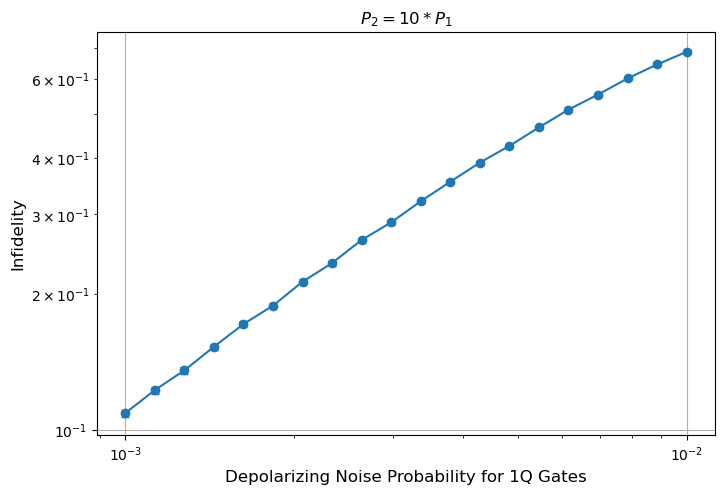

In [85]:
factor = 10
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0007433138106318652, 0.0008914682347541211, 0.001069137435146148, 0.001282190507070681, 0.0015376558417824115, 0.0018439444482243141, 0.0022111121374448406, 0.0026511642010266538, 0.003178403933754265, 0.0038098214060252942, 0.0045655091057137595, 0.005469072569664676, 0.0065479699883590845, 0.007833652494425422, 0.009361263518640653, 0.01116844821992661, 0.013292439221200743, 0.015763853582645152, 0.018594192641790068]


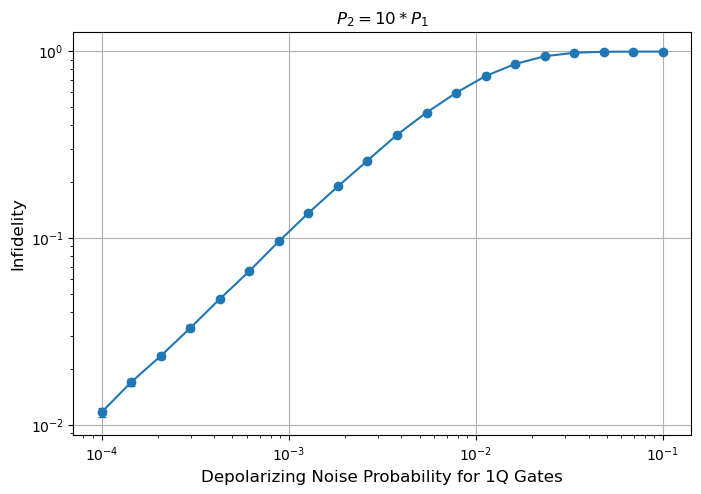

In [86]:
factor = 10
err_list_size = 20
error_list = np.logspace((-4), (-1), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

In [ ]:
factor = 10
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(
c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


## p*11

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


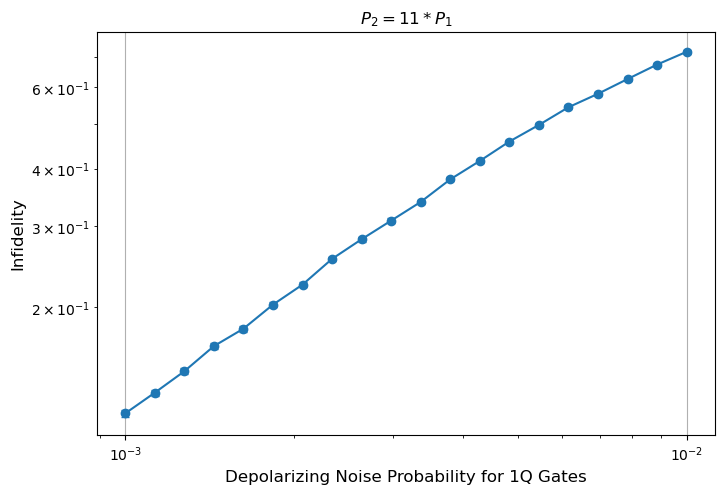

In [88]:
factor = 11
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


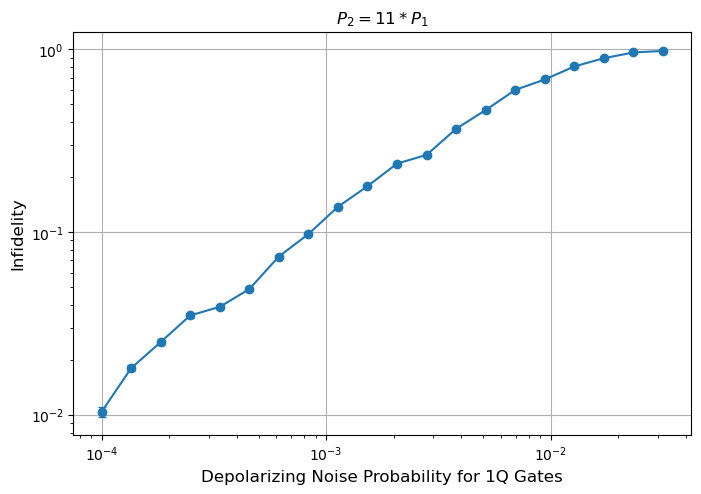

In [ ]:
factor = 11
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


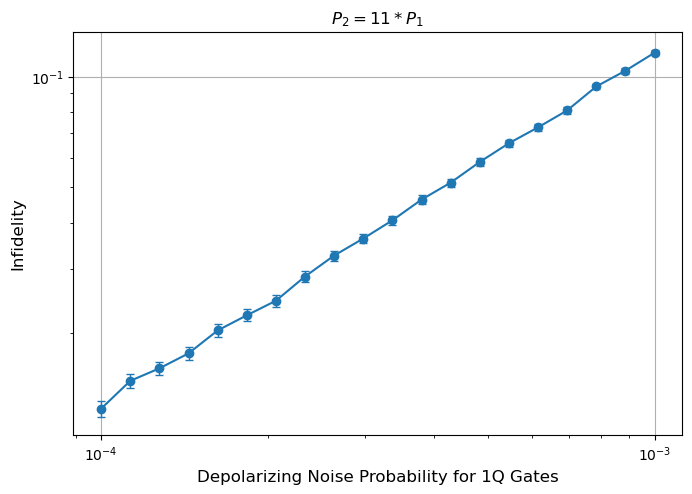

In [109]:
factor = 11
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

## p*12

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


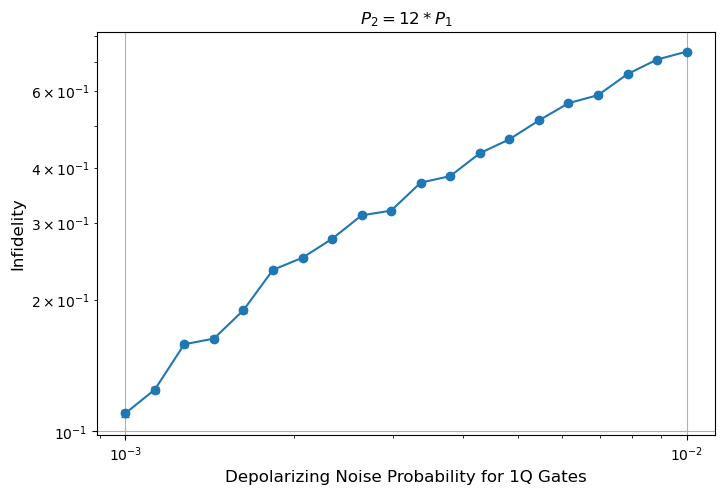

In [ ]:
factor = 12
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


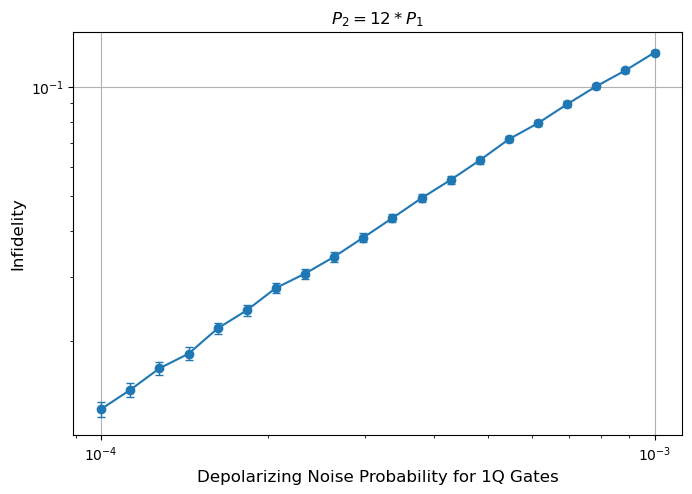

In [110]:
factor = 12
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

## p*13

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


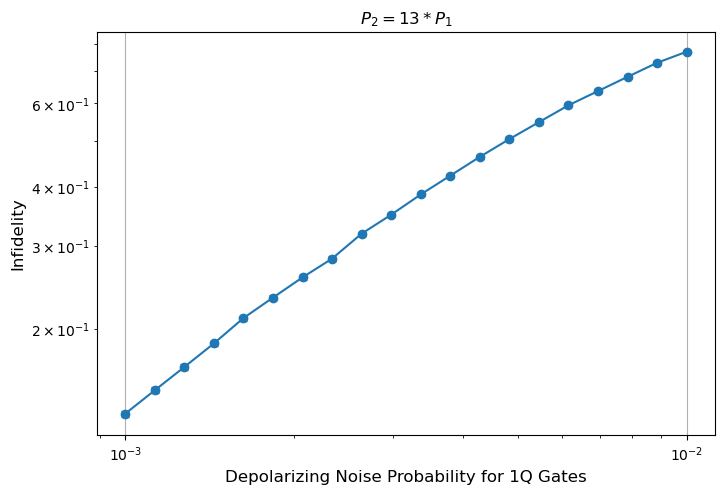

In [89]:
factor = 13
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


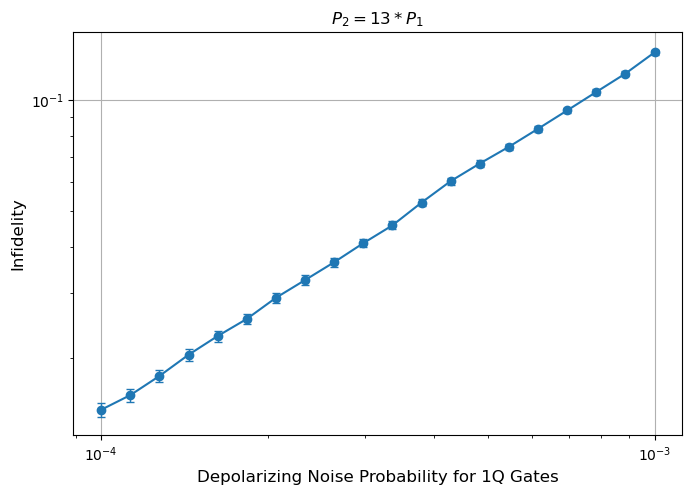

In [111]:
factor = 13
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

## p*14

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


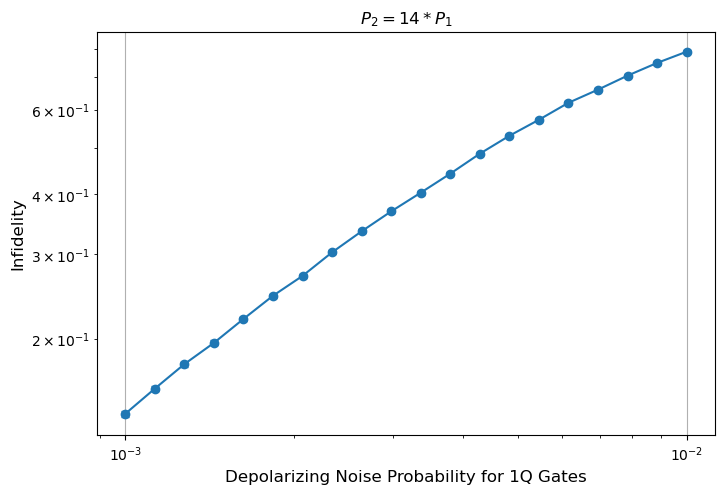

In [90]:
factor = 14
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


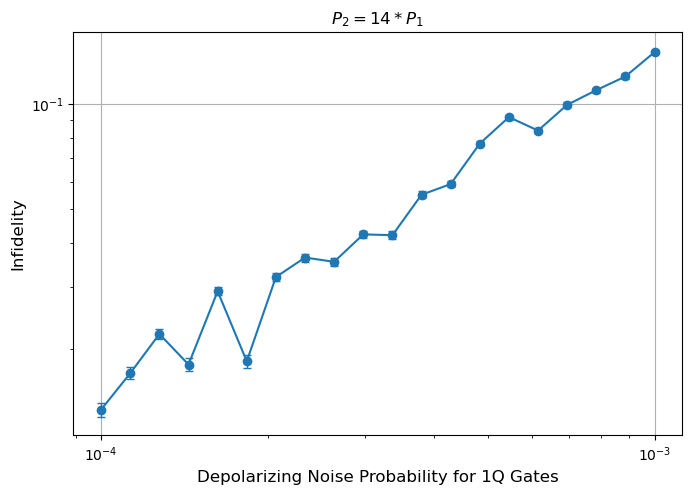

In [ ]:
factor = 14
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

## p*15

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


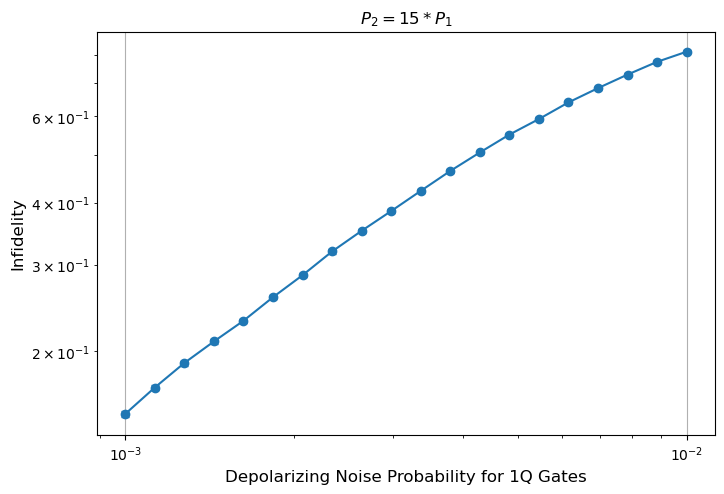

In [91]:
factor = 15
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


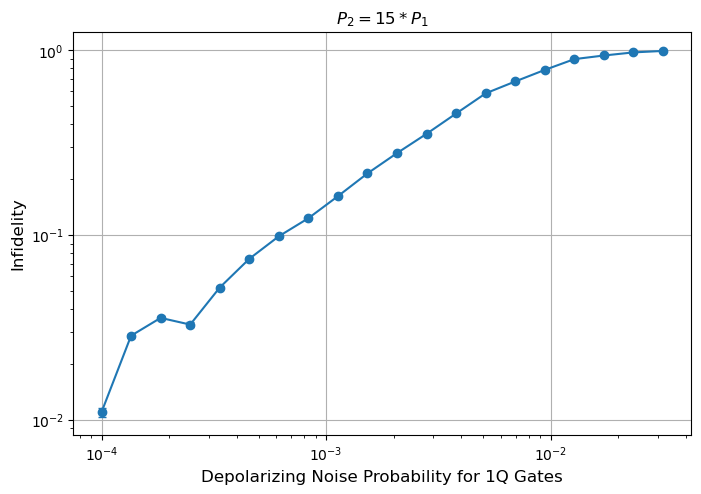

In [ ]:
factor = 15
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


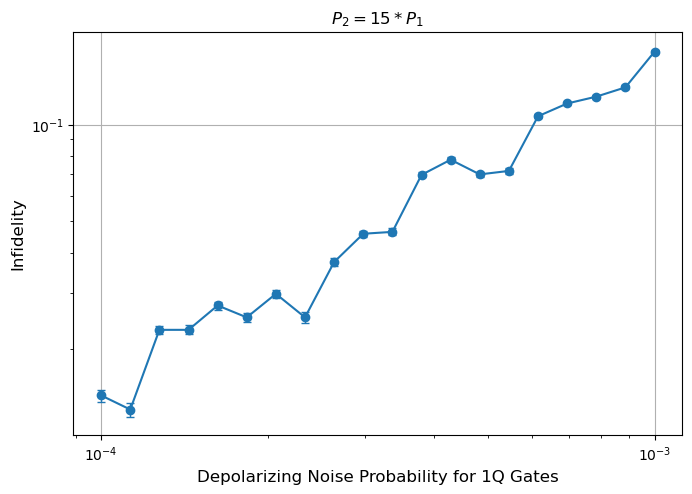

In [ ]:
factor = 15
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)

explore_depol(factor, err_list_size, error_list, shots = 10**(5))

# Biased Noise

In [92]:
def explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 1000):
    noise_list = []

    for p in error_list:
        # New noise model for each
        noise_model = NoiseModel()

        phase_p = p 
        bitflip_p = p/bias
        identity_p = 1 - phase_p - bitflip_p
        p_sum = phase_p + bitflip_p + identity_p
        
        phase_p /= p_sum
        bitflip_p /= p_sum
        identity_p /= p_sum
        
        # Assign 1q and 2q Pauli errors
        noise_1q = [
            (Pauli('I'),    identity_p ),
            (Pauli('X'),    bitflip_p),
            (Pauli('Z'),    phase_p),
        ]
        
        two_qubit_paulis = []
        for P1 in ['I','X','Z']:
            for P2 in ['I','X','Z']:
                two_qubit_paulis.append((Pauli(P1+P2), None))

        # unsure what to do here

        p2 = factor*p
        p3 = factor*p/bias
        p4 = 1 - p2 - p3
        
        p_sum_2 = p2+p3+p4

        p2 /= p_sum_2
        p3 /= p_sum_2
        p4 /= p_sum_2

        noise_2q = []
        for pauli, _ in two_qubit_paulis:
            if pauli.to_label() == 'II':
                prob = p4
            else:
                prob = (1 - p4)/8
            noise_2q.append((pauli, prob))
        

        # Apply depolarizing error with probability p
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

        # # Readout error 
        # readout_err = ReadoutError([[1-p2, p2],  
        #                         [p2, 1-p2]]) 
        # for i in range(0,7):
        #     noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)


    pauli_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in pauli_probs]


    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)



    plt.figure(figsize=(7, 5))
    plt.errorbar(
        pauli_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1, Z = {bias} * X$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

    return  pauli_probs,  fidelities, unc

        

## Bias=1000

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


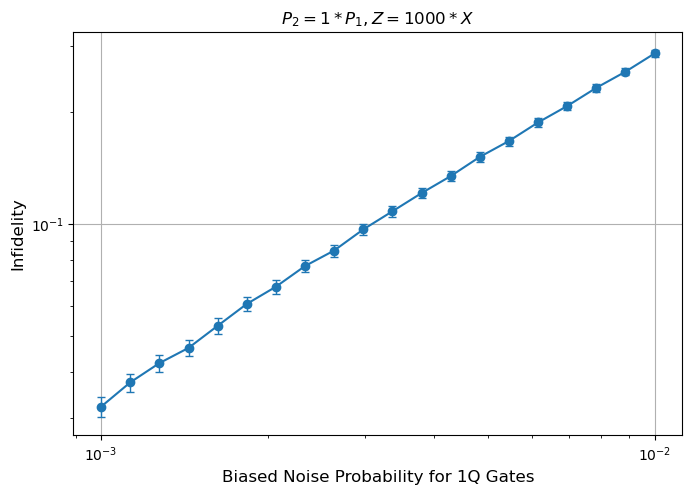

([0.001,
  0.0011288378916846896,
  0.0012742749857031334,
  0.0014384498882876629,
  0.001623776739188721,
  0.0018329807108324356,
  0.00206913808111479,
  0.002335721469090121,
  0.0026366508987303583,
  0.002976351441631319,
  0.003359818286283781,
  0.00379269019073225,
  0.004281332398719396,
  0.004832930238571752,
  0.00545559478116852,
  0.006158482110660267,
  0.0069519279617756054,
  0.007847599703514606,
  0.008858667904100823,
  0.01],
 [0.03221334368539841,
  0.03744313082303585,
  0.042185917227536174,
  0.04634973688764865,
  0.053153556547760994,
  0.06086703178933606,
  0.06771162159271127,
  0.07697724465169842,
  0.08474162159271115,
  0.09657496527811138,
  0.10802350629777369,
  0.12093440799721111,
  0.13433586697754873,
  0.15133289876688638,
  0.16696886624441132,
  0.18732470216576136,
  0.20735735701408664,
  0.23214589803374908,
  0.2564786031320615,
  0.28716409463487425],
 [0.0019590197548774234,
  0.002081261249798022,
  0.0022111121374448406,
  0.0023490

In [93]:
factor = 1
bias = 1000
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


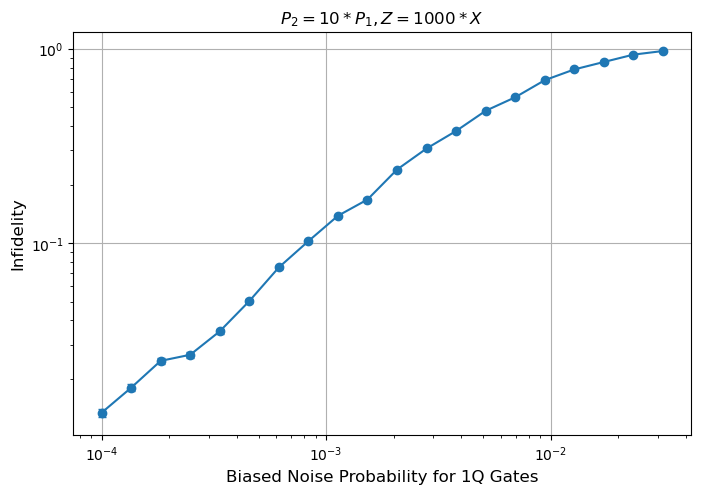

In [ ]:
factor = 1
bias = 1000
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)


pauli_prob_1000, fid_1000, unc_1000 = explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

In [1]:
factor = 1
bias = 1000
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)


explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

NameError: name 'np' is not defined

## Bias = 10

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


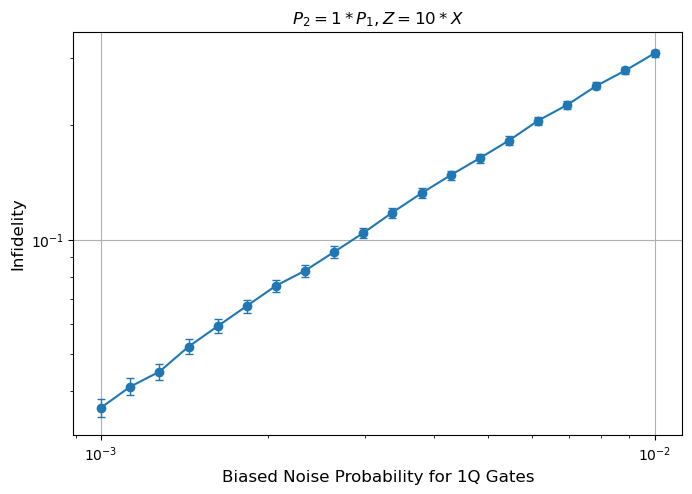

([0.001,
  0.0011288378916846896,
  0.0012742749857031334,
  0.0014384498882876629,
  0.001623776739188721,
  0.0018329807108324356,
  0.00206913808111479,
  0.002335721469090121,
  0.0026366508987303583,
  0.002976351441631319,
  0.003359818286283781,
  0.00379269019073225,
  0.004281332398719396,
  0.004832930238571752,
  0.00545559478116852,
  0.006158482110660267,
  0.0069519279617756054,
  0.007847599703514606,
  0.008858667904100823,
  0.01],
 [0.036180081306185996,
  0.04107244198596105,
  0.04496299926686098,
  0.05232501552809843,
  0.05922501552809856,
  0.06695355654776114,
  0.07566162159271106,
  0.08288544125282382,
  0.09286071989327349,
  0.10416621139608617,
  0.11790878493822388,
  0.1325708011994614,
  0.1478097679438487,
  0.16390324318542393,
  0.18230470216576145,
  0.20562491502812397,
  0.226198947550599,
  0.253845898033749,
  0.2787212579803867,
  0.3091785528820742],
 [0.0019590197548774234,
  0.002081261249798022,
  0.0022111121374448406,
  0.002349042419794

In [94]:
factor = 1
bias = 10
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


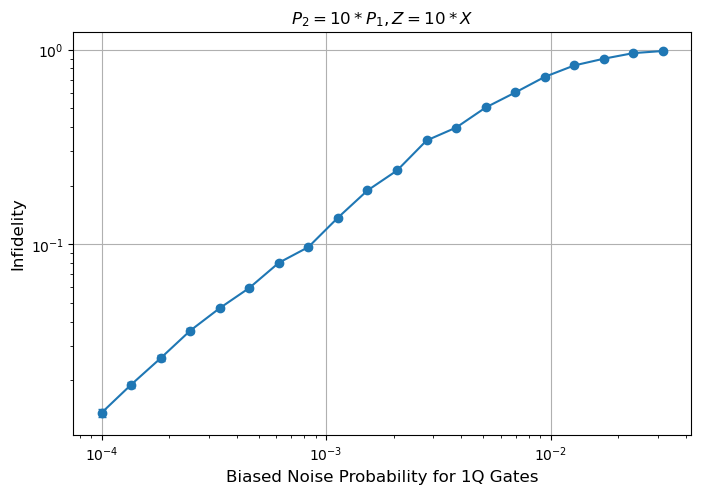

In [ ]:
factor = 1
bias = 10
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)


pauli_prob_10, fid_10, unc_10 = explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

## Bias = 100000

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


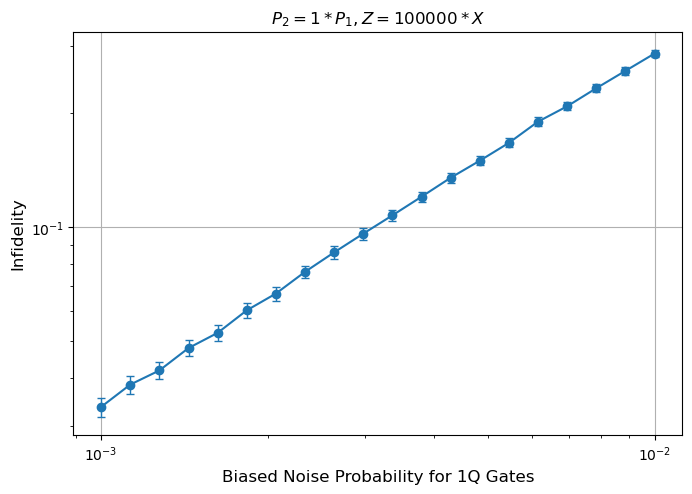

([0.001,
  0.0011288378916846896,
  0.0012742749857031334,
  0.0014384498882876629,
  0.001623776739188721,
  0.0018329807108324356,
  0.00206913808111479,
  0.002335721469090121,
  0.0026366508987303583,
  0.002976351441631319,
  0.003359818286283781,
  0.00379269019073225,
  0.004281332398719396,
  0.004832930238571752,
  0.00545559478116852,
  0.006158482110660267,
  0.0069519279617756054,
  0.007847599703514606,
  0.008858667904100823,
  0.01],
 [0.03360222912359856,
  0.03847862232584853,
  0.04192535994663604,
  0.048035917227535974,
  0.05267668737079856,
  0.06039904805057372,
  0.06686453955338623,
  0.0763007198932738,
  0.08587419513484884,
  0.09621385071631117,
  0.1075123917359736,
  0.12039462085957375,
  0.13509865338204885,
  0.14984122692418633,
  0.1669761611460987,
  0.18994289876688653,
  0.20850289876688655,
  0.23266847157588655,
  0.25854332449161155,
  0.2871788159944241],
 [0.0019590197548774234,
  0.002081261249798022,
  0.0022111121374448406,
  0.00234904241

In [95]:
factor = 1
bias = 100000
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


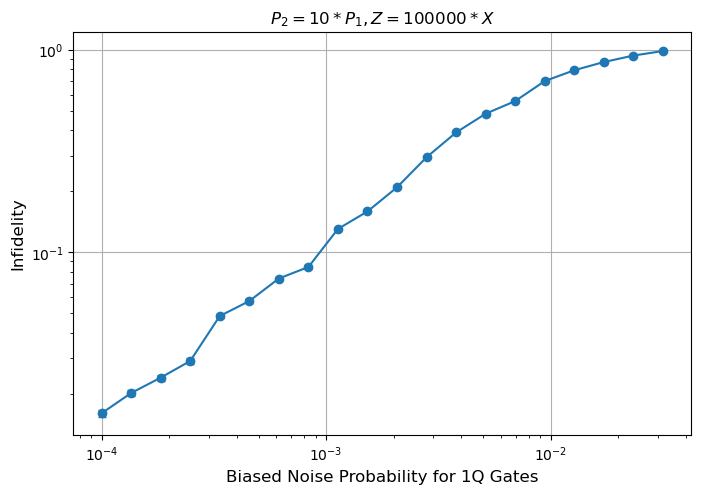

In [ ]:
factor = 1
bias = 100000
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)


pauli_prob_100000, fid_100000, unc_100000 =  explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


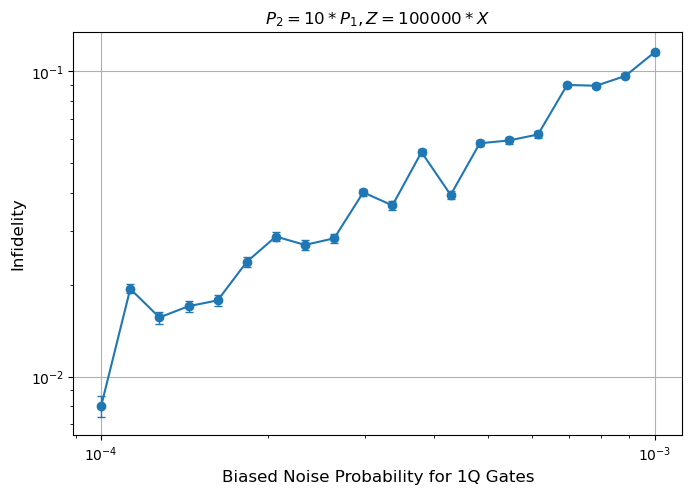

In [ ]:
factor = 1
bias = 100000
err_list_size = 20
error_list = np.logspace((-4), (-3), err_list_size)


explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

## bias = 100

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


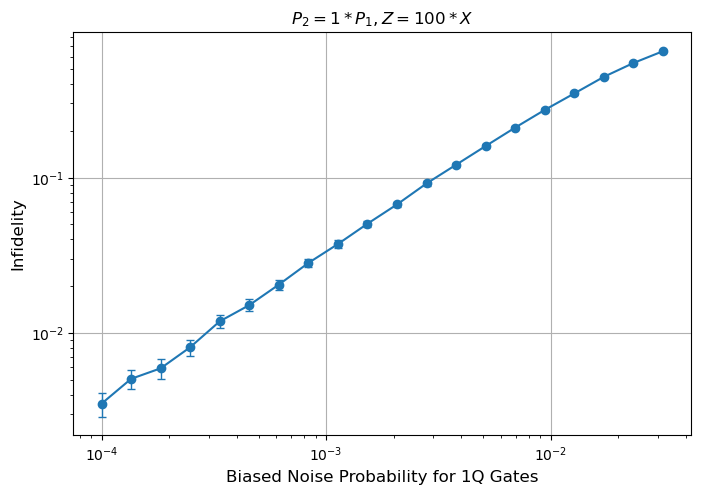

In [96]:
factor = 1
bias = 100
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)


pauli_prob_100, fid_100, unc_100 =  explore_phase_bias_noise(factor, bias, err_list_size, error_list, shots = 10**(5))

## comparing biases

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


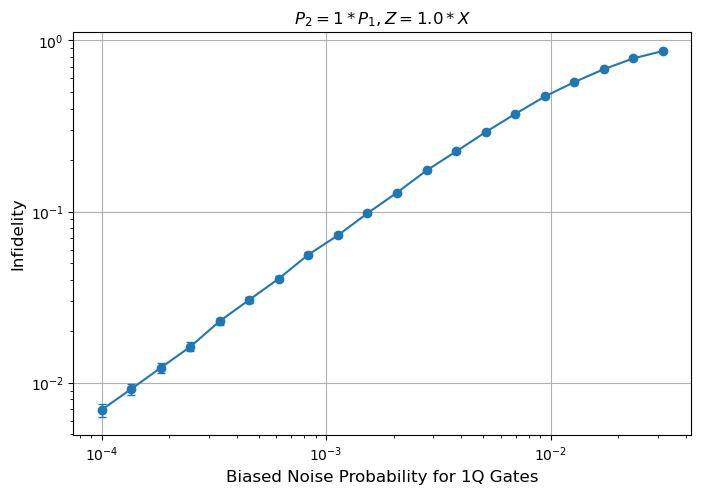

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


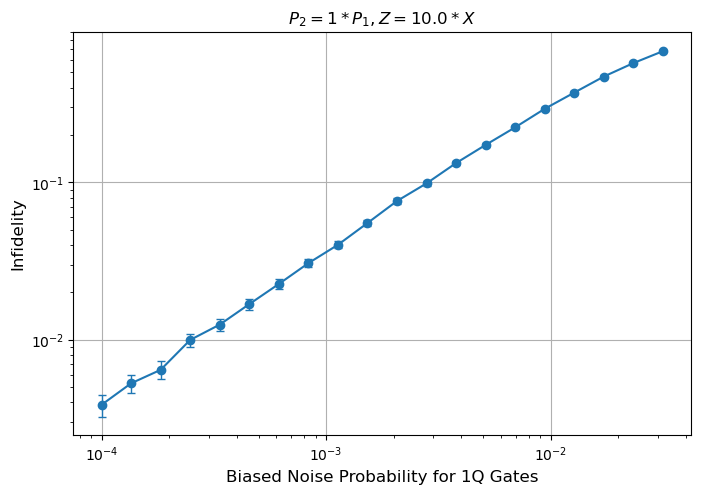

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


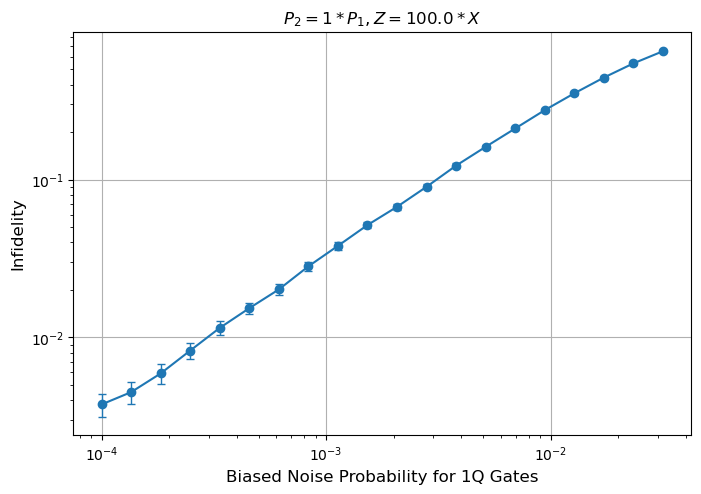

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


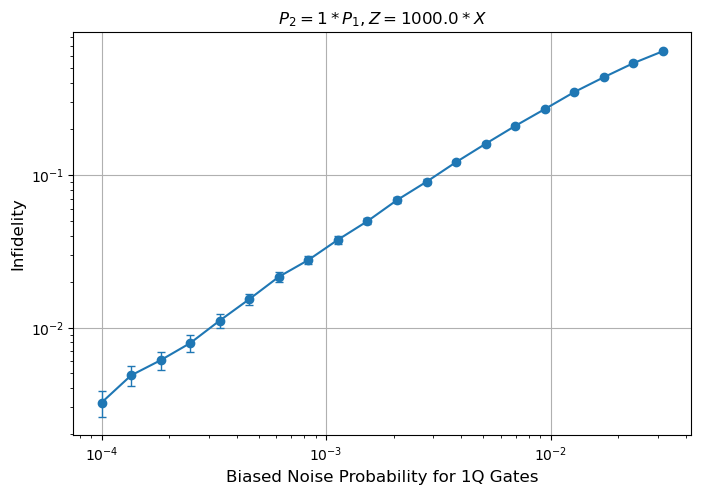

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


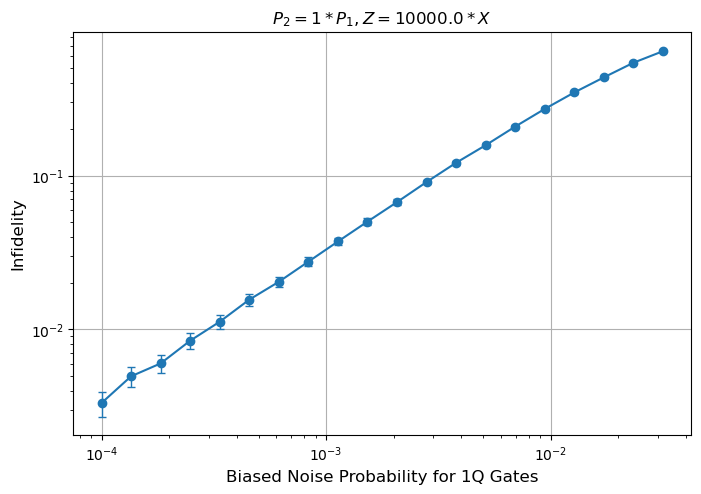

[0.000619775430297136, 0.0007211342853660984, 0.0008390642401473815, 0.0009762714698014237, 0.0011359023454920356, 0.0013216140344426317, 0.0015376558417824115, 0.0017889625868204818, 0.002081261249798021, 0.002421191904122073, 0.002816443446239895, 0.003275903660793544, 0.0038098214060252942, 0.004429975678972342, 0.005149841221815697, 0.005984731860022312, 0.006951888792166115, 0.008070458061148473, 0.009361263518640653, 0.010846218631072695]


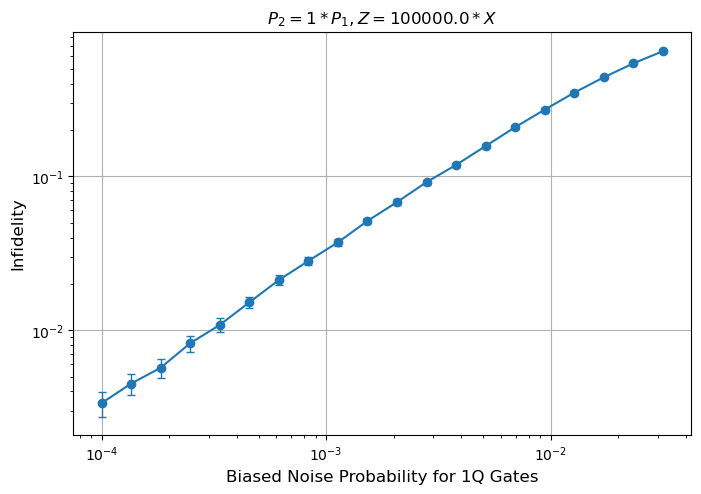

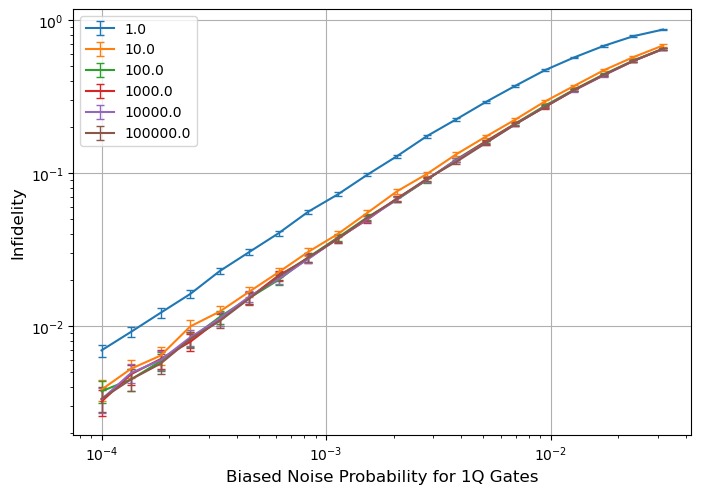

In [112]:
factor = 1
bias_list_size = 6
bias_list = np.logspace(0,5,bias_list_size)
err_list_size = 20
error_list = np.logspace((-4), (-1.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


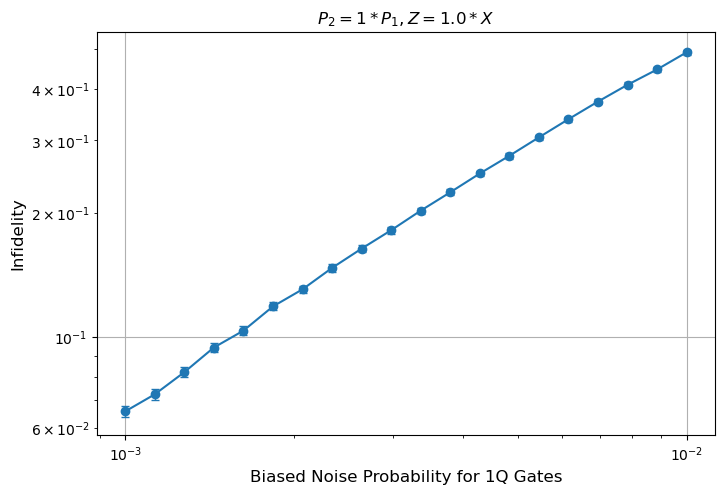

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


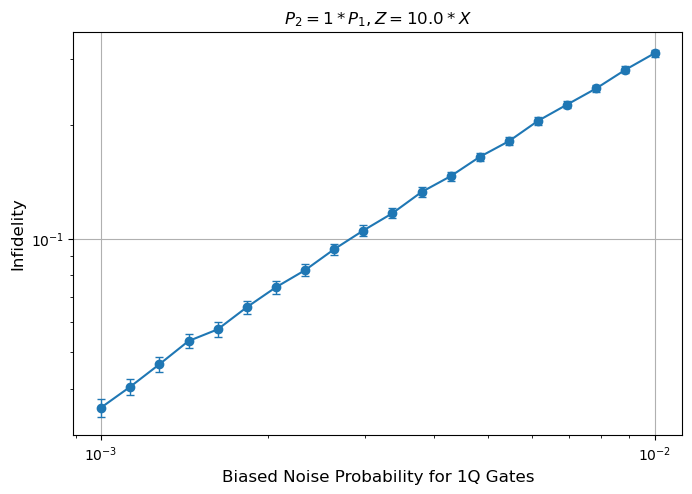

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


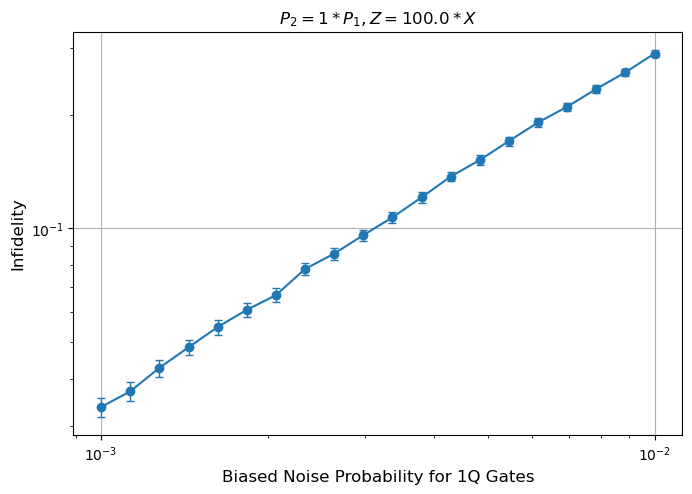

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


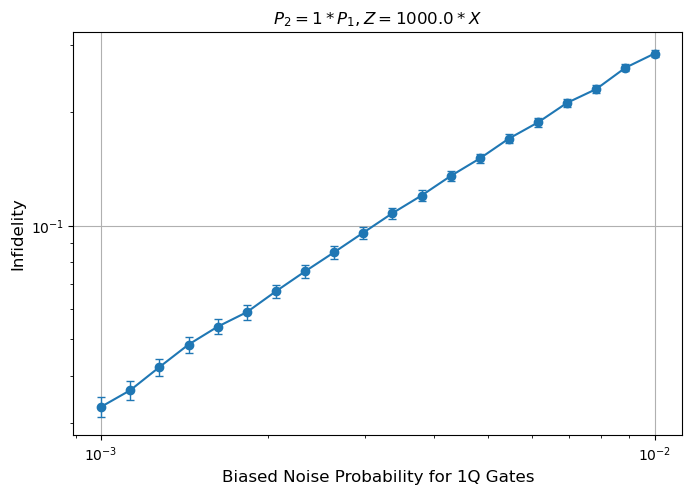

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


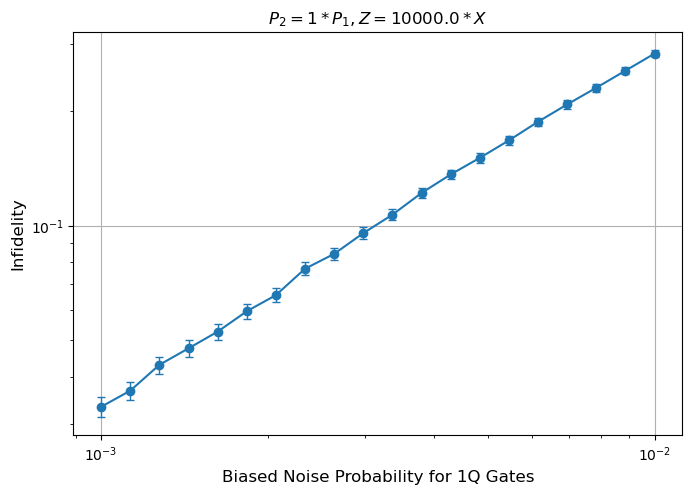

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


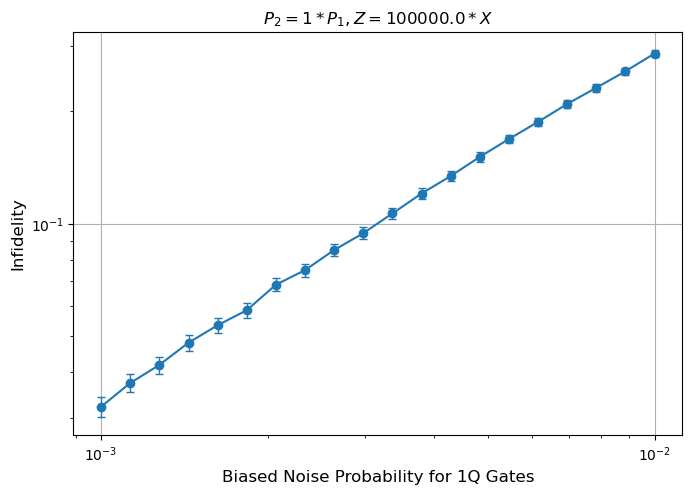

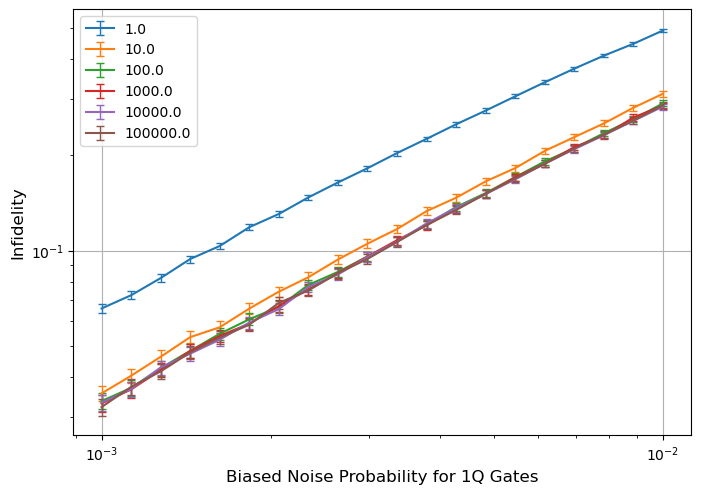

In [97]:
factor = 1
bias_list_size = 6
bias_list = np.logspace(0,5,bias_list_size)
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




[0.0011020147122113592, 0.0012523419274739123, 0.0014231563245027043, 0.001617241014730564, 0.0018377529844926645, 0.002088271343382913, 0.002372850857131926, 0.00269608087558839, 0.003063149493516765, 0.003479912335002542]


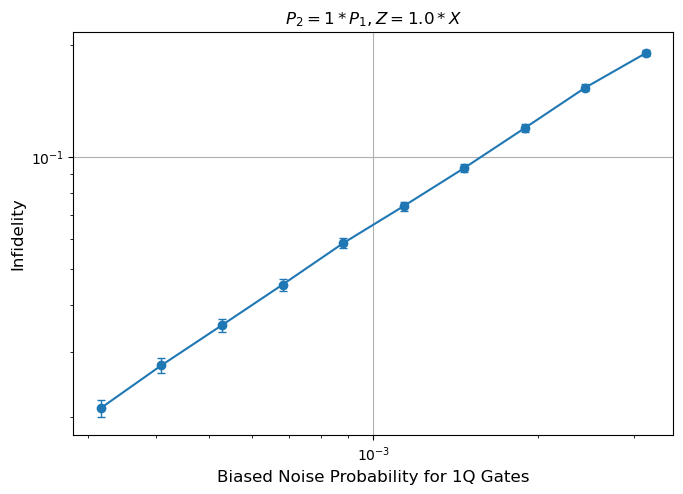

[0.0011020147122113592, 0.0012523419274739123, 0.0014231563245027043, 0.001617241014730564, 0.0018377529844926645, 0.002088271343382913, 0.002372850857131926, 0.00269608087558839, 0.003063149493516765, 0.003479912335002542]


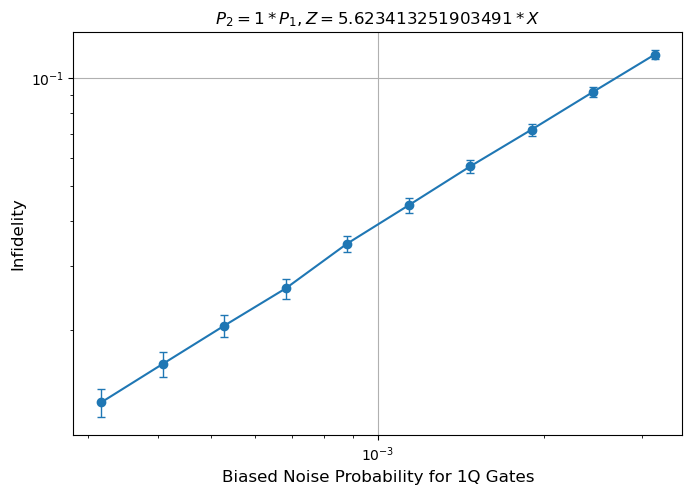

[0.0011020147122113592, 0.0012523419274739123, 0.0014231563245027043, 0.001617241014730564, 0.0018377529844926645, 0.002088271343382913, 0.002372850857131926, 0.00269608087558839, 0.003063149493516765, 0.003479912335002542]


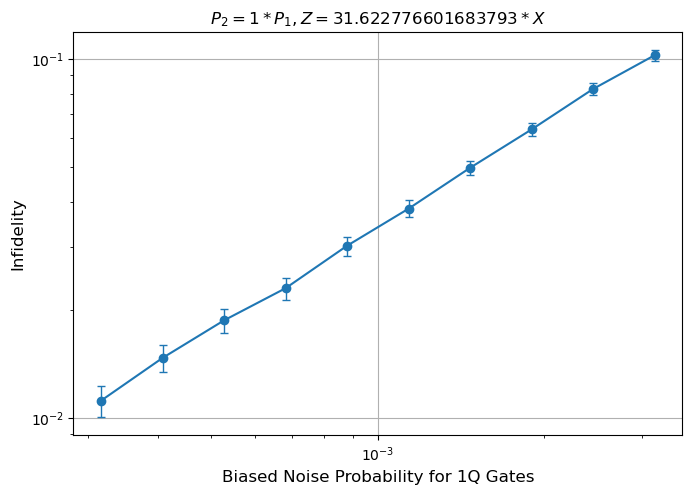

[0.0011020147122113592, 0.0012523419274739123, 0.0014231563245027043, 0.001617241014730564, 0.0018377529844926645, 0.002088271343382913, 0.002372850857131926, 0.00269608087558839, 0.003063149493516765, 0.003479912335002542]


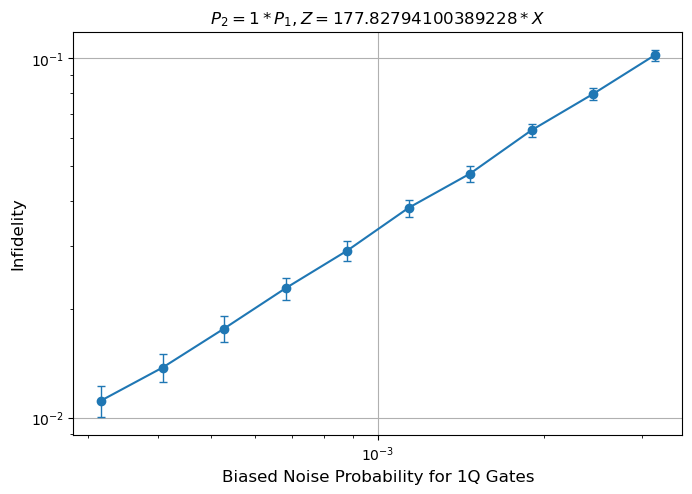

[0.0011020147122113592, 0.0012523419274739123, 0.0014231563245027043, 0.001617241014730564, 0.0018377529844926645, 0.002088271343382913, 0.002372850857131926, 0.00269608087558839, 0.003063149493516765, 0.003479912335002542]


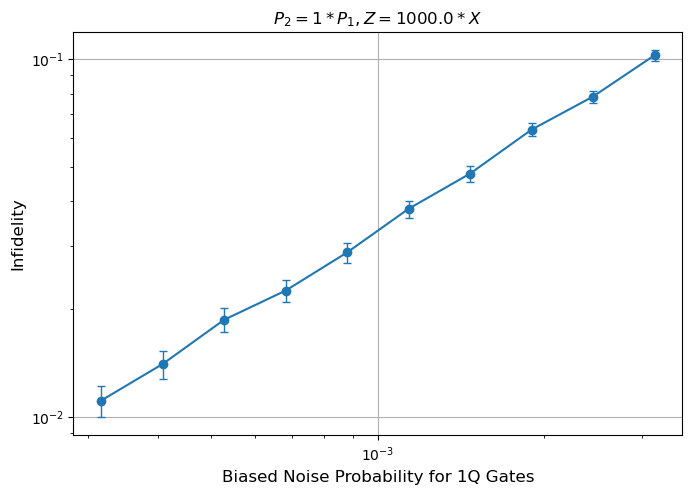

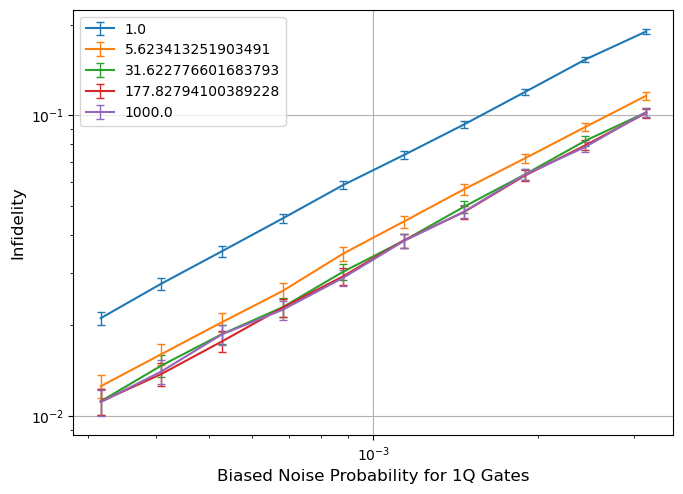

In [113]:
factor = 1
bias_list_size = 5
bias_list = np.logspace(0,3,bias_list_size)
err_list_size = 10
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


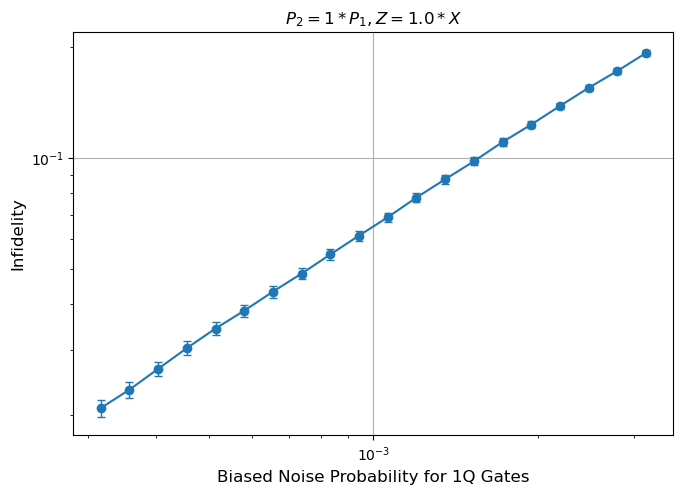

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


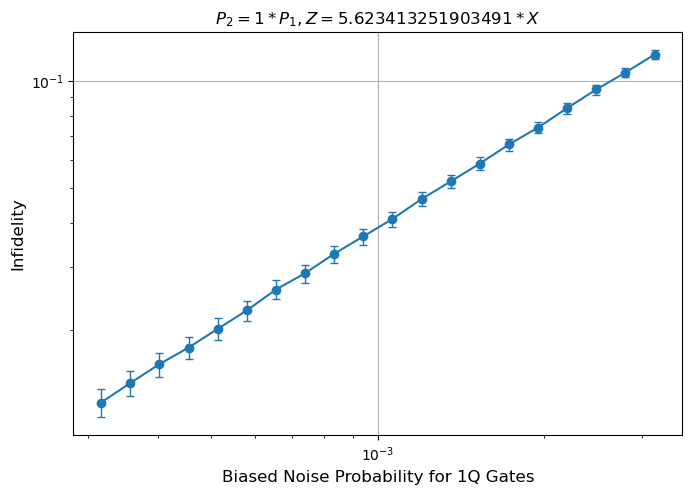

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


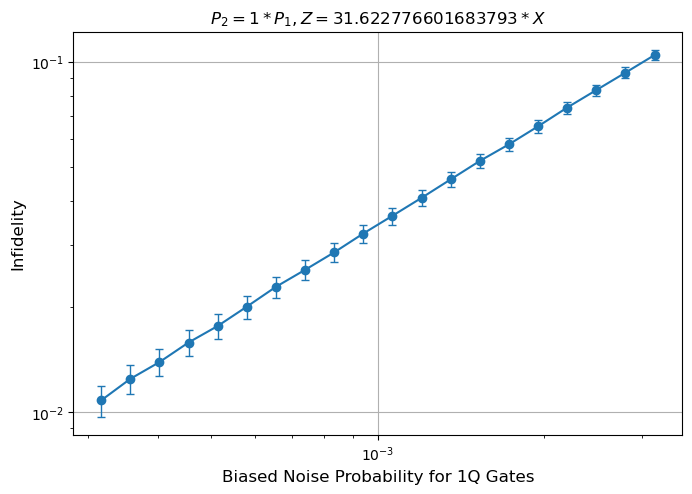

In [ ]:
factor = 1
bias_list_size = 5
bias_list = np.logspace(0,3,bias_list_size)
err_list_size = 20
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise(factor, bi, err_list_size, error_list, shots = 10**(6))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




[0.0019590197548774234, 0.0020055451280182103, 0.002053173065391986, 0.0021019295214803058, 0.0021518410489552607, 0.002202934811521681, 0.002255238596963639, 0.002308780830392648, 0.00236359058769444, 0.0024196976091704313, 0.0024771323133693903, 0.0025359258111039115, 0.0025961099196455334, 0.002657717177091385, 0.0027207808568941987, 0.002785334982546502, 0.0028514143424085334, 0.0029190545046682104, 0.002988291832420011, 0.0030591634988481834, 0.003131707502497994, 0.0032059626826169666, 0.0032819687345461996, 0.00335976622513963, 0.003439396608187028, 0.0035209022398139046, 0.0036043263938290294, 0.003689713276987259, 0.0037771080441324455, 0.003866556813181724, 0.003958106679908981, 0.004051805732481391, 0.004147703065698653, 0.004245848794880148, 0.004346294069340161, 0.004449091085386222, 0.004554293098769699, 0.0046619544365117714, 0.00477213050802114, 0.004884877815412642, 0.005000253962928223, 0.005118317665353197, 0.005239128755311795, 0.005362748189316027, 0.00548923805243

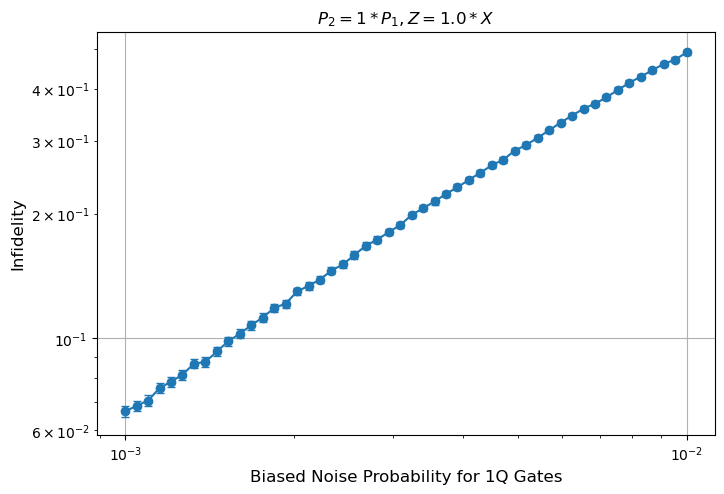

[0.0019590197548774234, 0.0020055451280182103, 0.002053173065391986, 0.0021019295214803058, 0.0021518410489552607, 0.002202934811521681, 0.002255238596963639, 0.002308780830392648, 0.00236359058769444, 0.0024196976091704313, 0.0024771323133693903, 0.0025359258111039115, 0.0025961099196455334, 0.002657717177091385, 0.0027207808568941987, 0.002785334982546502, 0.0028514143424085334, 0.0029190545046682104, 0.002988291832420011, 0.0030591634988481834, 0.003131707502497994, 0.0032059626826169666, 0.0032819687345461996, 0.00335976622513963, 0.003439396608187028, 0.0035209022398139046, 0.0036043263938290294, 0.003689713276987259, 0.0037771080441324455, 0.003866556813181724, 0.003958106679908981, 0.004051805732481391, 0.004147703065698653, 0.004245848794880148, 0.004346294069340161, 0.004449091085386222, 0.004554293098769699, 0.0046619544365117714, 0.00477213050802114, 0.004884877815412642, 0.005000253962928223, 0.005118317665353197, 0.005239128755311795, 0.005362748189316027, 0.00548923805243

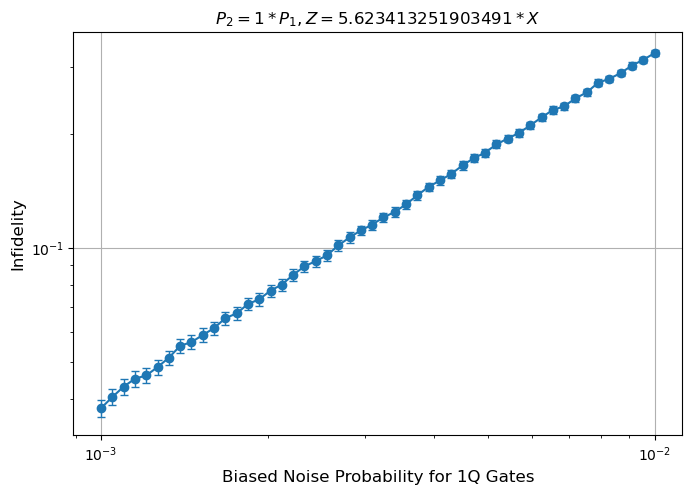

[0.0019590197548774234, 0.0020055451280182103, 0.002053173065391986, 0.0021019295214803058, 0.0021518410489552607, 0.002202934811521681, 0.002255238596963639, 0.002308780830392648, 0.00236359058769444, 0.0024196976091704313, 0.0024771323133693903, 0.0025359258111039115, 0.0025961099196455334, 0.002657717177091385, 0.0027207808568941987, 0.002785334982546502, 0.0028514143424085334, 0.0029190545046682104, 0.002988291832420011, 0.0030591634988481834, 0.003131707502497994, 0.0032059626826169666, 0.0032819687345461996, 0.00335976622513963, 0.003439396608187028, 0.0035209022398139046, 0.0036043263938290294, 0.003689713276987259, 0.0037771080441324455, 0.003866556813181724, 0.003958106679908981, 0.004051805732481391, 0.004147703065698653, 0.004245848794880148, 0.004346294069340161, 0.004449091085386222, 0.004554293098769699, 0.0046619544365117714, 0.00477213050802114, 0.004884877815412642, 0.005000253962928223, 0.005118317665353197, 0.005239128755311795, 0.005362748189316027, 0.00548923805243

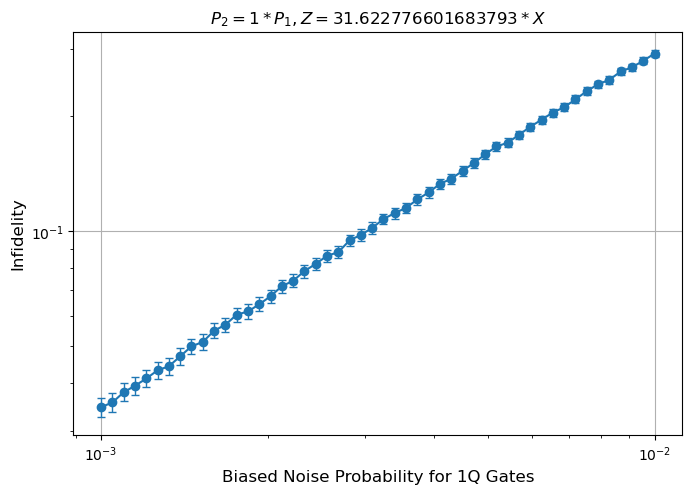

[0.0019590197548774234, 0.0020055451280182103, 0.002053173065391986, 0.0021019295214803058, 0.0021518410489552607, 0.002202934811521681, 0.002255238596963639, 0.002308780830392648, 0.00236359058769444, 0.0024196976091704313, 0.0024771323133693903, 0.0025359258111039115, 0.0025961099196455334, 0.002657717177091385, 0.0027207808568941987, 0.002785334982546502, 0.0028514143424085334, 0.0029190545046682104, 0.002988291832420011, 0.0030591634988481834, 0.003131707502497994, 0.0032059626826169666, 0.0032819687345461996, 0.00335976622513963, 0.003439396608187028, 0.0035209022398139046, 0.0036043263938290294, 0.003689713276987259, 0.0037771080441324455, 0.003866556813181724, 0.003958106679908981, 0.004051805732481391, 0.004147703065698653, 0.004245848794880148, 0.004346294069340161, 0.004449091085386222, 0.004554293098769699, 0.0046619544365117714, 0.00477213050802114, 0.004884877815412642, 0.005000253962928223, 0.005118317665353197, 0.005239128755311795, 0.005362748189316027, 0.00548923805243

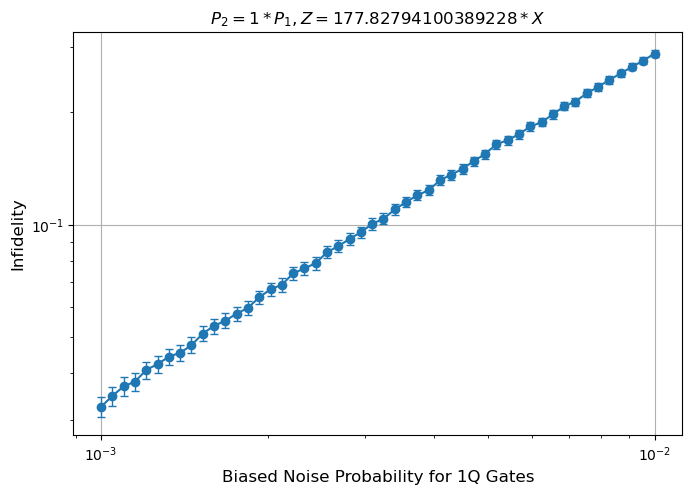

[0.0019590197548774234, 0.0020055451280182103, 0.002053173065391986, 0.0021019295214803058, 0.0021518410489552607, 0.002202934811521681, 0.002255238596963639, 0.002308780830392648, 0.00236359058769444, 0.0024196976091704313, 0.0024771323133693903, 0.0025359258111039115, 0.0025961099196455334, 0.002657717177091385, 0.0027207808568941987, 0.002785334982546502, 0.0028514143424085334, 0.0029190545046682104, 0.002988291832420011, 0.0030591634988481834, 0.003131707502497994, 0.0032059626826169666, 0.0032819687345461996, 0.00335976622513963, 0.003439396608187028, 0.0035209022398139046, 0.0036043263938290294, 0.003689713276987259, 0.0037771080441324455, 0.003866556813181724, 0.003958106679908981, 0.004051805732481391, 0.004147703065698653, 0.004245848794880148, 0.004346294069340161, 0.004449091085386222, 0.004554293098769699, 0.0046619544365117714, 0.00477213050802114, 0.004884877815412642, 0.005000253962928223, 0.005118317665353197, 0.005239128755311795, 0.005362748189316027, 0.00548923805243

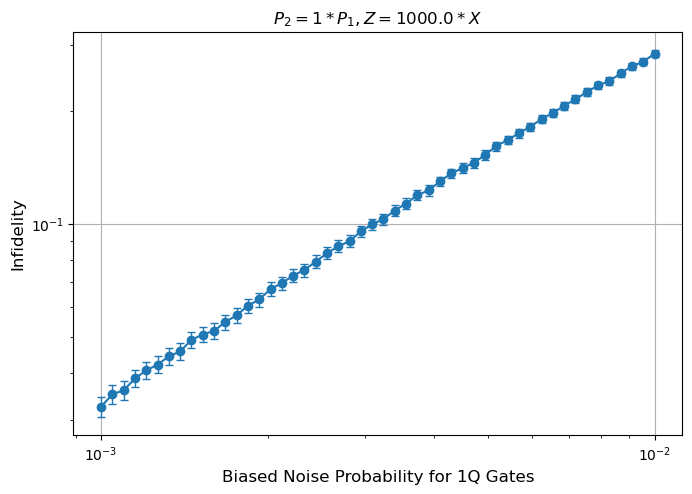

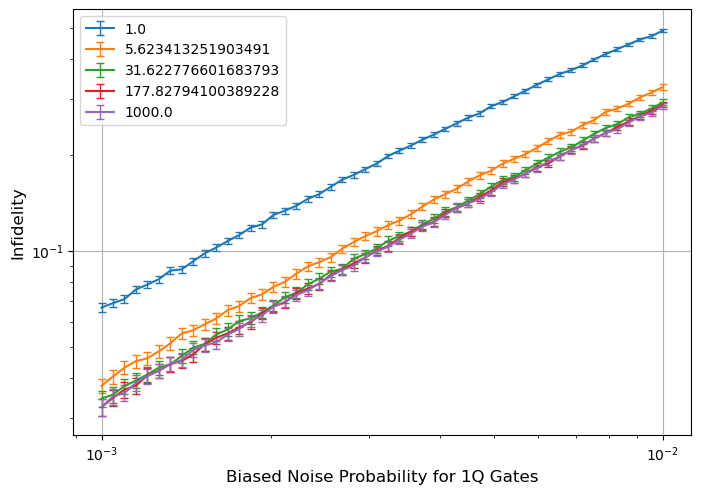

In [98]:
factor = 1
bias_list_size = 5
bias_list = np.logspace(0,3, bias_list_size)
err_list_size = 50
error_list = np.logspace((-3), (-2), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

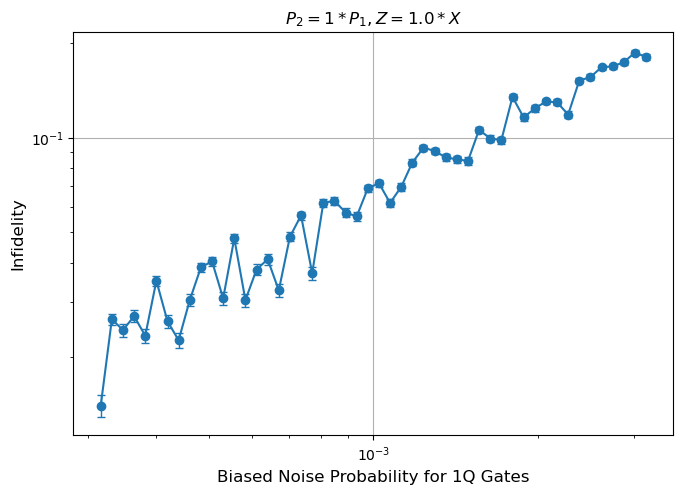

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

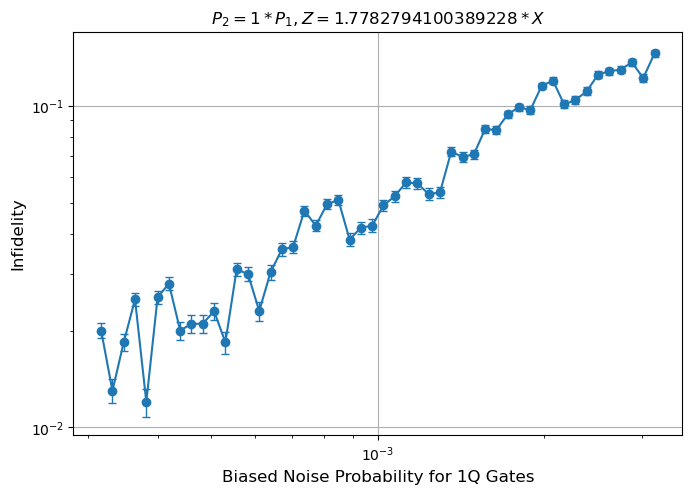

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

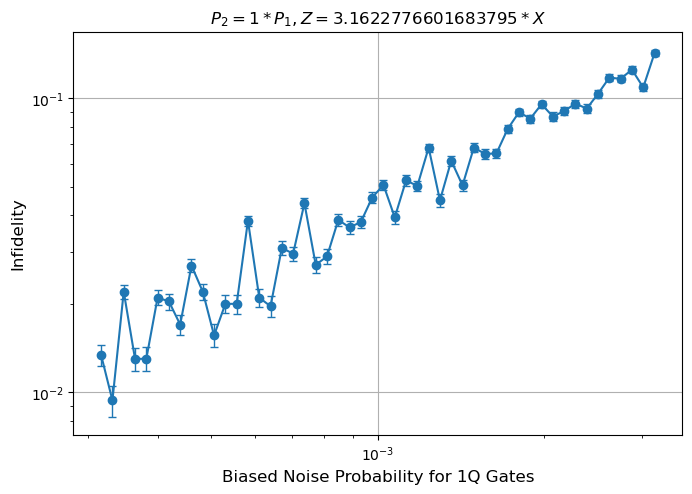

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

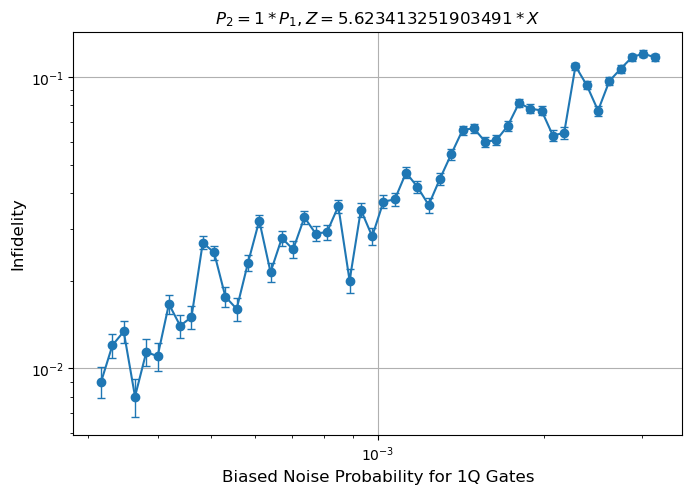

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

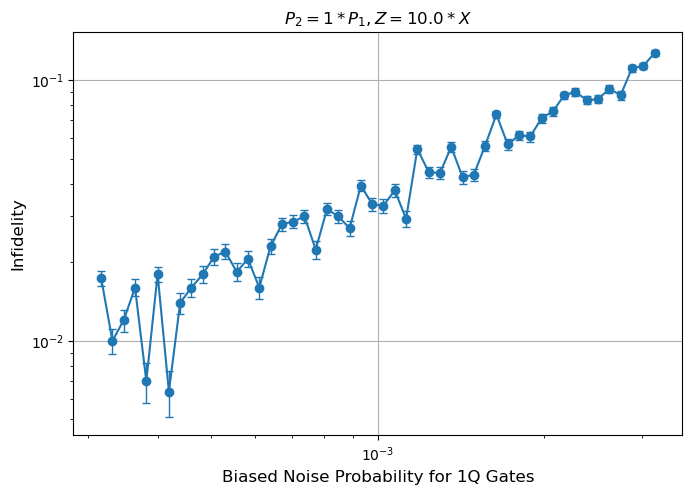

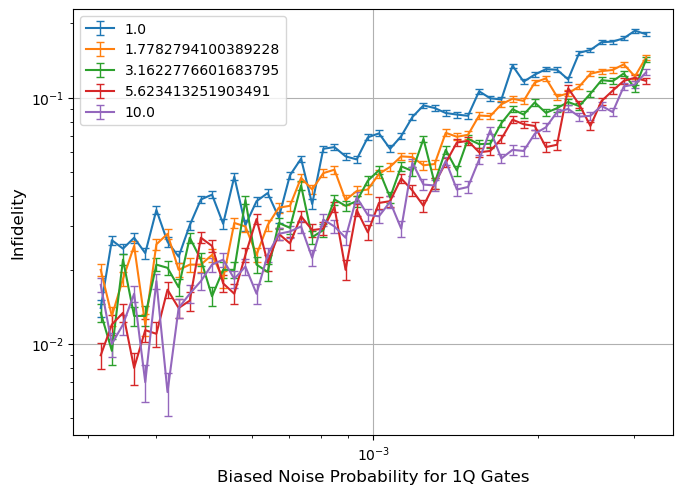

In [ ]:
factor = 1
bias_list_size = 5
bias_list = np.logspace(0,1, bias_list_size)
err_list_size = 50
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




# Bias Noise 2

In [ ]:
def explore_phase_bias_noise_2(factor, bias, err_list_size, error_list, shots = 1000):
    noise_list = []

    for p in error_list:
        # New noise model for each
        noise_model = NoiseModel()

        phase_p = (p *bias)/(1+bias)
        bitflip_p = (p )/(1+bias)
        identity_p = 1 - phase_p - bitflip_p
        p_sum = phase_p + bitflip_p + identity_p
        
        phase_p /= p_sum
        bitflip_p /= p_sum
        identity_p /= p_sum
        
        # Assign 1q and 2q Pauli errors
        noise_1q = [
            (Pauli('I'),    identity_p ),
            (Pauli('X'),    bitflip_p),
            (Pauli('Z'),    phase_p),
        ]
        
        two_qubit_paulis = []
        for P1 in ['I','X','Z']:
            for P2 in ['I','X','Z']:
                two_qubit_paulis.append((Pauli(P1+P2), None))

        # unsure what to do here

        p2 = factor*(p *bias)/(1+bias)
        p3 = factor*(p )/(1+bias)
        p4 = 1 - p2 - p3
        
        p_sum_2 = p2+p3+p4

        p2 /= p_sum_2
        p3 /= p_sum_2
        p4 /= p_sum_2

        noise_2q = []
        for pauli, _ in two_qubit_paulis:
            if pauli.to_label() == 'II':
                prob = p4
            else:
                prob = (1 - p4)/8
            noise_2q.append((pauli, prob))
        

        # Apply depolarizing error with probability p
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

        # # Readout error 
        # readout_err = ReadoutError([[1-p2, p2],  
        #                         [p2, 1-p2]]) 
        # for i in range(0,7):
        #     noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)

    pauli_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in pauli_probs]

    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        pauli_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1, Z = {bias} * X$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

    return  pauli_probs,  fidelities, unc

        

[0.0019590197548774234, 0.0020055451280182103, 0.002053173065391986, 0.0021019295214803058, 0.0021518410489552607, 0.002202934811521681, 0.002255238596963639, 0.002308780830392648, 0.00236359058769444, 0.0024196976091704313, 0.0024771323133693903, 0.0025359258111039115, 0.0025961099196455334, 0.002657717177091385, 0.0027207808568941987, 0.002785334982546502, 0.0028514143424085334, 0.0029190545046682104, 0.002988291832420011, 0.0030591634988481834, 0.003131707502497994, 0.0032059626826169666, 0.0032819687345461996, 0.00335976622513963, 0.003439396608187028, 0.0035209022398139046, 0.0036043263938290294, 0.003689713276987259, 0.0037771080441324455, 0.003866556813181724, 0.003958106679908981, 0.004051805732481391, 0.004147703065698653, 0.004245848794880148, 0.004346294069340161, 0.004449091085386222, 0.004554293098769699, 0.0046619544365117714, 0.00477213050802114, 0.004884877815412642, 0.005000253962928223, 0.005118317665353197, 0.005239128755311795, 0.005362748189316027, 0.00548923805243

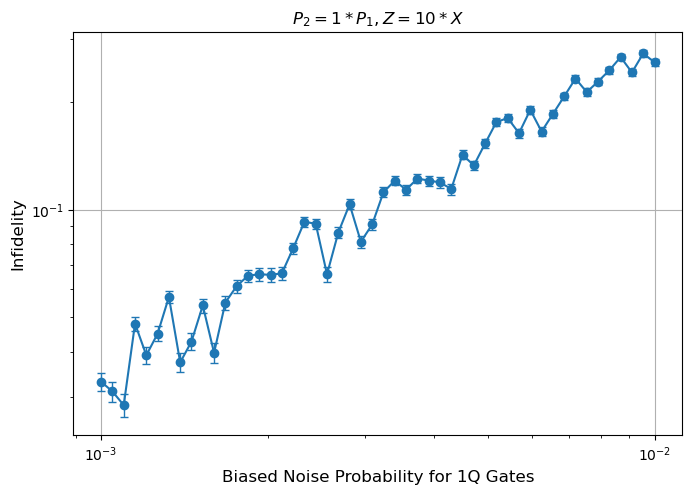

([0.001,
  0.0010481131341546852,
  0.0010985411419875584,
  0.0011513953993264468,
  0.0012067926406393288,
  0.0012648552168552957,
  0.0013257113655901094,
  0.0013894954943731374,
  0.0014563484775012444,
  0.0015264179671752333,
  0.0015998587196060573,
  0.0016768329368110084,
  0.0017575106248547913,
  0.0018420699693267163,
  0.0019306977288832496,
  0.0020235896477251575,
  0.0021209508879201904,
  0.0022229964825261957,
  0.002329951810515372,
  0.0024420530945486497,
  0.002559547922699536,
  0.0026826957952797246,
  0.002811768697974231,
  0.0029470517025518097,
  0.0030888435964774815,
  0.0032374575428176433,
  0.00339322177189533,
  0.0035564803062231283,
  0.003727593720314938,
  0.003906939937054617,
  0.004094915062380423,
  0.004291934260128779,
  0.004498432668969444,
  0.004714866363457394,
  0.004941713361323833,
  0.005179474679231213,
  0.005428675439323859,
  0.005689866029018293,
  0.005963623316594642,
  0.0062505519252739694,
  0.006551285568595509,
  0.0068

In [ ]:
factor = 1
bias = 10
err_list_size = 50
error_list = np.logspace((-3), (-2), err_list_size)



explore_phase_bias_noise_2(factor, bias, err_list_size, error_list, shots = 10**(5))

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


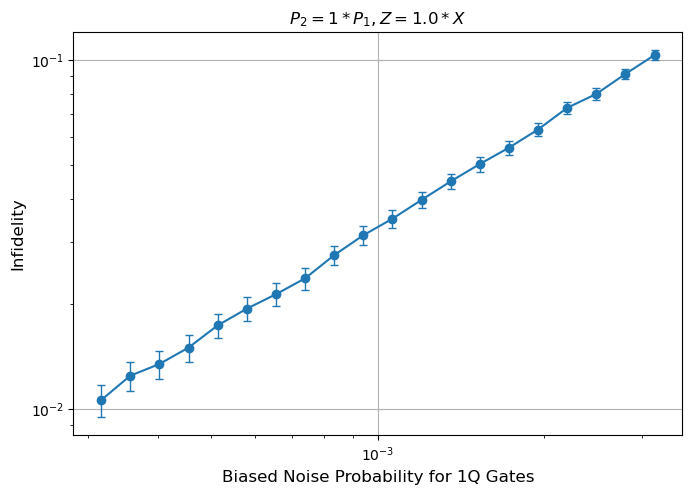

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


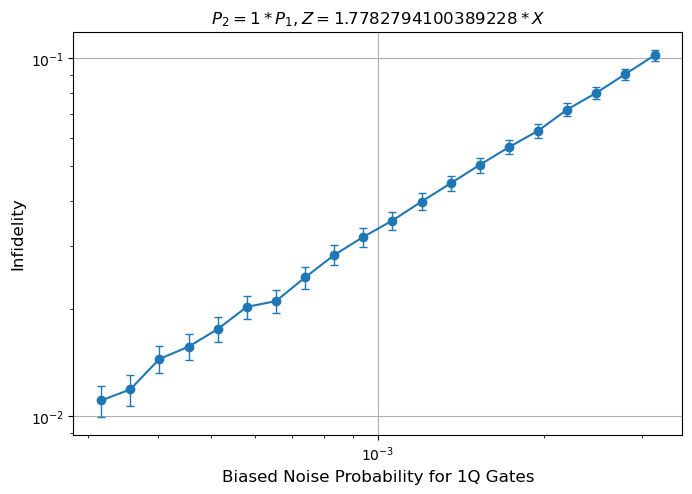

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


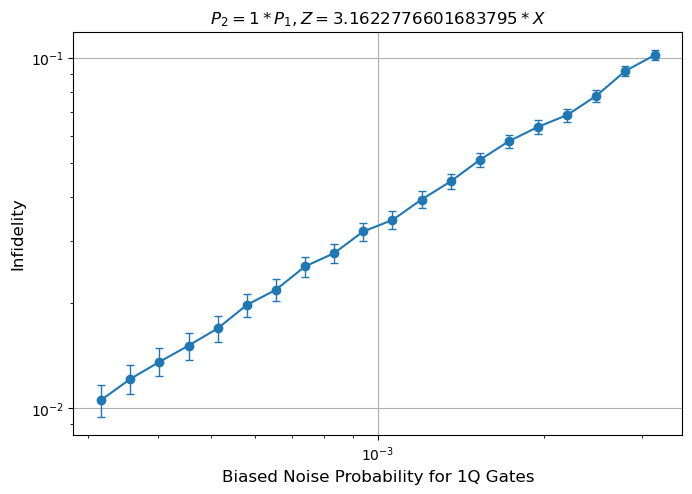

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


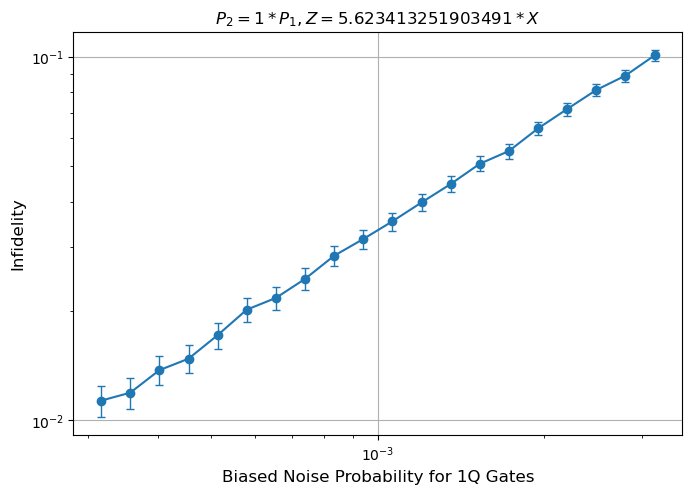

[0.0011020147122113592, 0.001170831321548153, 0.0012439419981237305, 0.0013216140344426317, 0.00140413123101509, 0.0014917948898355666, 0.001584924862388196, 0.0016838606540800437, 0.0017889625868204818, 0.0019006130212105164, 0.002019217639462832, 0.0021452067897213428, 0.002279036891863726, 0.002421191904122073, 0.0025721848489094193, 0.002732559395050136, 0.0029028914921272668, 0.0030837910508161267, 0.003275903660793544, 0.003479912335002542]


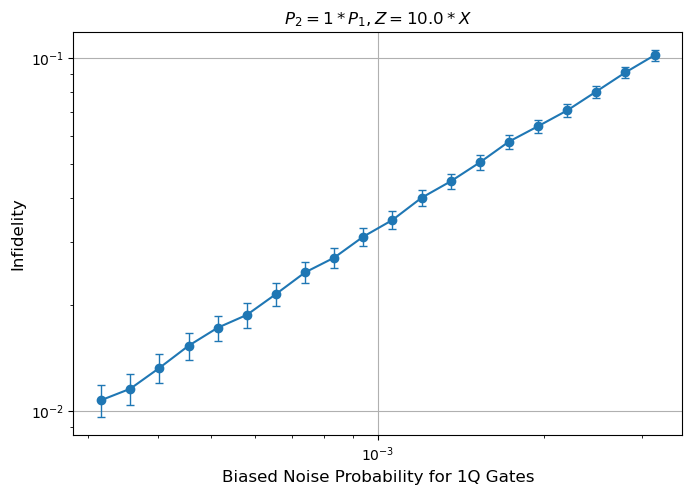

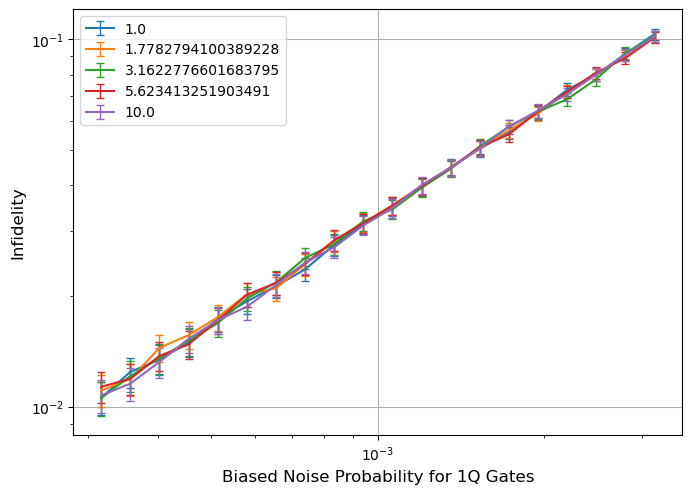

In [100]:
factor = 1
bias_list_size = 5
bias_list = np.logspace(0,1, bias_list_size)
err_list_size = 20
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise_2(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




In [ ]:
factor = 1
bias_list_size = 4
bias_list = np.logspace(1,3, bias_list_size)
err_list_size = 20
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise_2(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

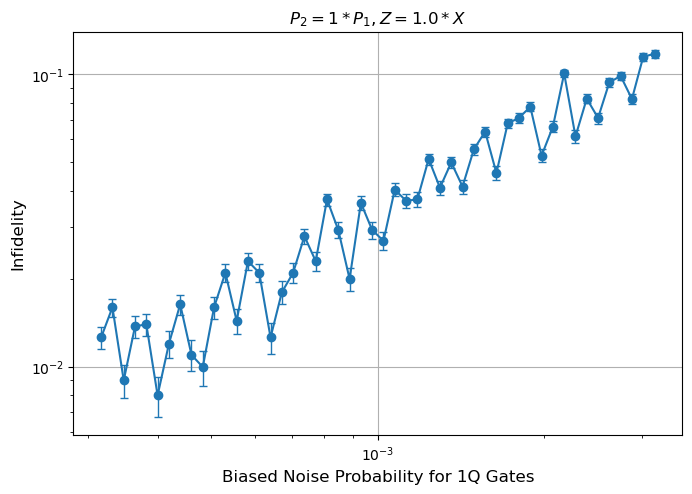

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

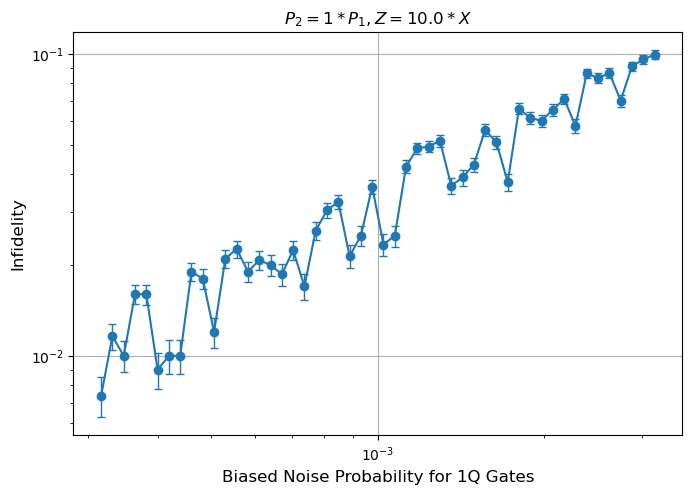

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

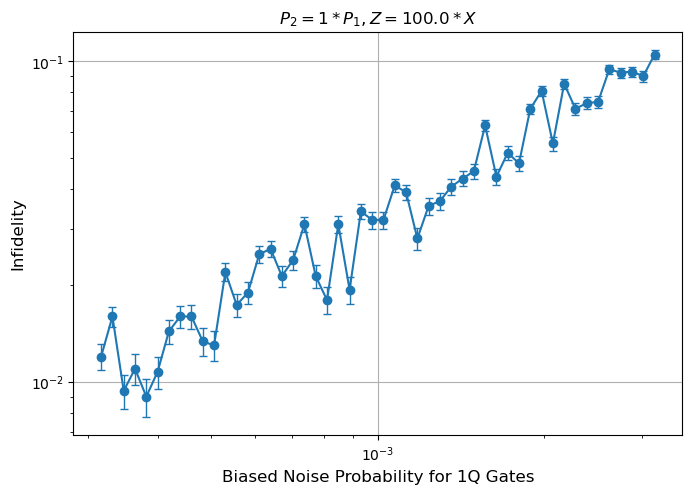

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

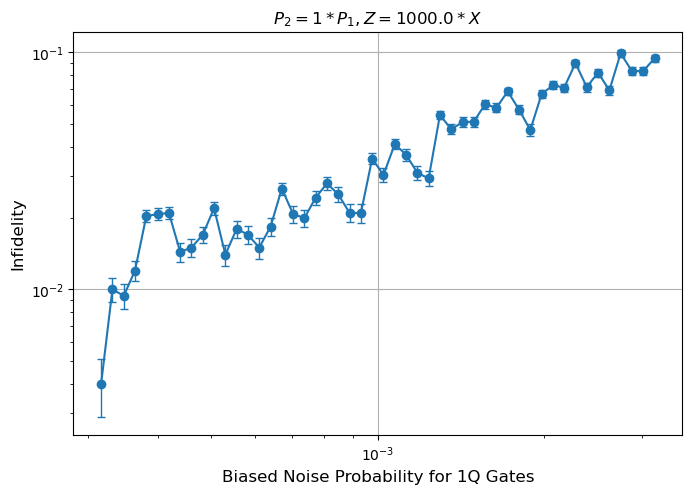

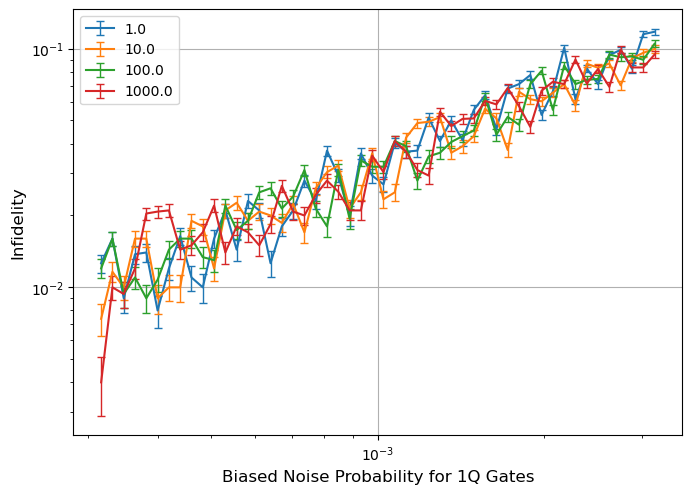

In [ ]:
factor = 1
bias_list_size = 4
bias_list = np.logspace(0,2, bias_list_size)
err_list_size = 20
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise_2(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




# Bias Noise 3

In [ ]:
def explore_phase_bias_noise_3(factor, bias, err_list_size, error_list, shots = 1000):
    noise_list = []

    for p in error_list:
        # New noise model for each
        noise_model = NoiseModel()

        phase_p = p 
        bitflip_p = p/bias
        identity_p = 1 - phase_p - bitflip_p
        p_sum = phase_p + bitflip_p + identity_p
        
        phase_p /= p_sum
        bitflip_p /= p_sum
        identity_p /= p_sum
        
        # Assign 1q and 2q Pauli errors
        noise_1q = [
            (Pauli('I'),    identity_p ),
            (Pauli('X'),    bitflip_p),
            (Pauli('Z'),    phase_p),
        ]
        
        two_qubit_paulis = []
        for P1 in ['I','X','Z']:
            for P2 in ['I','X','Z']:
                two_qubit_paulis.append((Pauli(P1+P2), None))

        # unsure what to do here

        p2 = factor*p
        p3 = factor*p/bias
        p4 = 1 - p2 - p3
        
        p_sum_2 = p2+p3+p4

        p2 /= p_sum_2
        p3 /= p_sum_2
        p4 /= p_sum_2

        noise_2q = []
        for pauli, _ in two_qubit_paulis:
            if pauli.to_label() == 'II':
                prob = p4
            else:
                prob = (1 - p4)/8
            noise_2q.append((pauli, prob))
        

        # Apply depolarizing error with probability p
        #noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

        # # Readout error 
        # readout_err = ReadoutError([[1-p2, p2],  
        #                         [p2, 1-p2]]) 
        # for i in range(0,7):
        #     noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)


    pauli_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in pauli_probs]


    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)



    plt.figure(figsize=(7, 5))
    plt.errorbar(
        pauli_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1, Z = {bias} * X$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

    return  pauli_probs,  fidelities, unc

        

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

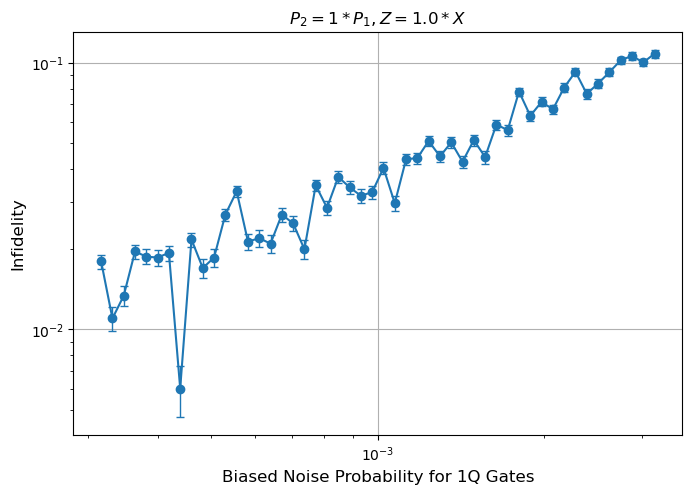

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

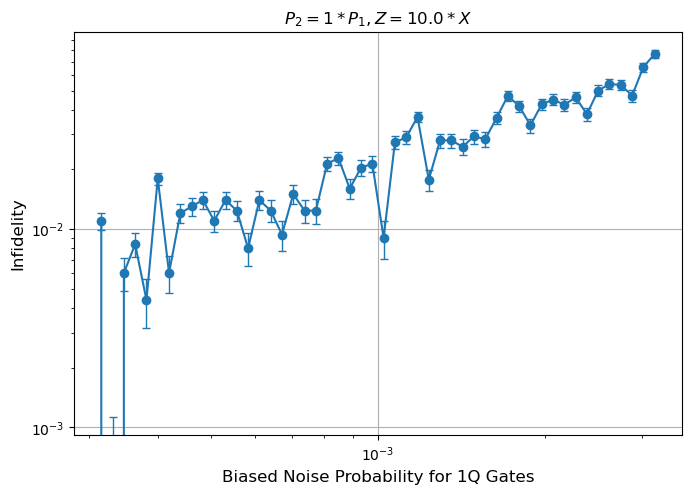

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

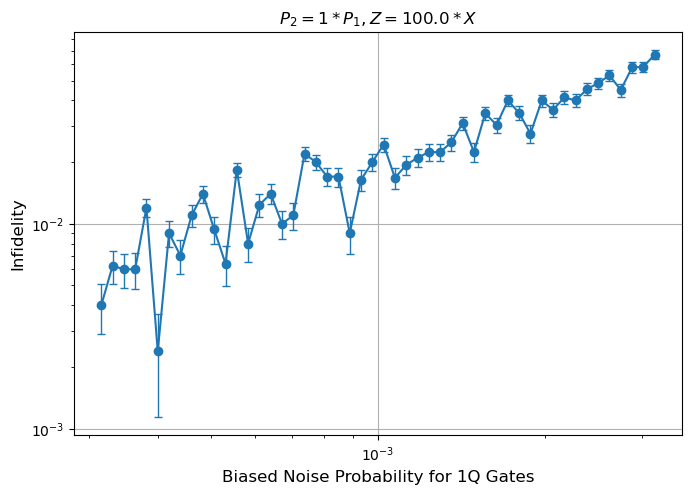

[0.0011020147122113592, 0.0011282053874139743, 0.001155018091770437, 0.0011824675675759498, 0.0012105689042622514, 0.001239337546405903, 0.0012687893019090956, 0.0012989403503557574, 0.0013298072515457405, 0.0013614069542097996, 0.001393756804908059, 0.0014268745571145822, 0.001460778380490612, 0.001495486870348975, 0.0015310190573120319, 0.0015673944171654976, 0.0016046328809102884, 0.00164275484501448, 0.0016817811818672609, 0.00172173325043665, 0.0017626329071325263, 0.001804502516876334, 0.001847364964378611, 0.0018912436656251962, 0.0019361625795727576, 0.001982146220053904, 0.0020292196678918795, 0.0020774085832244047, 0.002126739218035878, 0.002177238428896665, 0.0022289336899077284, 0.0022818531058483448, 0.002336025425524023, 0.0023914800553111516, 0.0024482470728941796, 0.002506357241190407, 0.0025658420224566113, 0.002626733592570883, 0.002689064855482036, 0.002752869457817934, 0.0028181818036429273, 0.00288503706935334, 0.00295347121869863, 0.0030235210179143557, 0.00309522

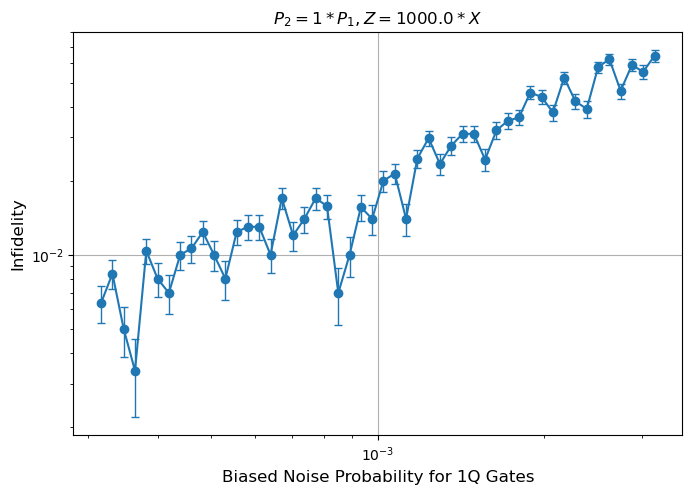

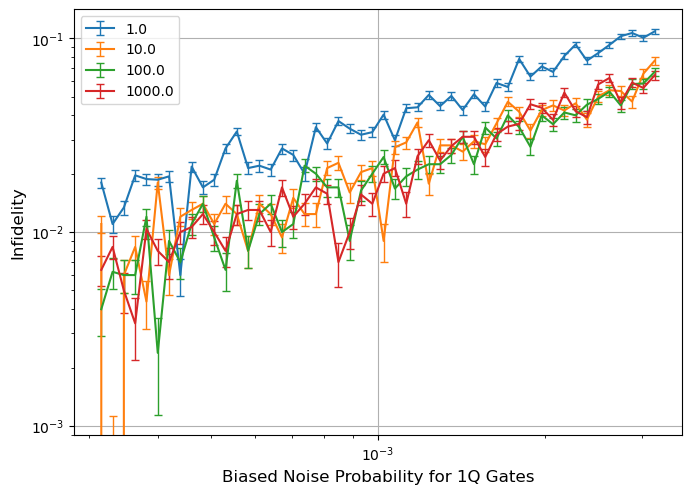

In [ ]:
factor = 1
bias_list_size = 4
bias_list = np.logspace(0,3, bias_list_size)
err_list_size = 50
error_list = np.logspace((-3.5), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise_3(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




[0.000619775430297136, 0.0006420057118958271, 0.0006650331781779217, 0.0006888863966432237, 0.0007135949563141068, 0.00073918950401682, 0.0007657017819238015, 0.0007931646663977171, 0.0008216122081789037, 0.0008510796739588235, 0.0008816035893830402, 0.0009132217835281077, 0.0009459734348975704, 0.0009798991189830424, 0.0010150408574370387, 0.0010514421689048383, 0.001089148121563176, 0.0011282053874139743, 0.0011686622983816026, 0.0012105689042622514, 0.0012539770325739861, 0.0012989403503557574, 0.0013455144279631733, 0.001393756804908059, 0.0014437270577877944, 0.001495486870348975, 0.0015491001057281713, 0.0016046328809102884, 0.001662153643442282, 0.00172173325043665, 0.0017834450498951703, 0.001847364964378611, 0.0019135715770426686, 0.001982146220053904, 0.002053173065391986, 0.002126739218035878, 0.002202934811521681, 0.0022818531058483448, 0.00236359058769444, 0.0024482470728941796, 0.0025359258111039115, 0.002626733592570883, 0.0027207808568941987, 0.0028181818036429273, 0.00

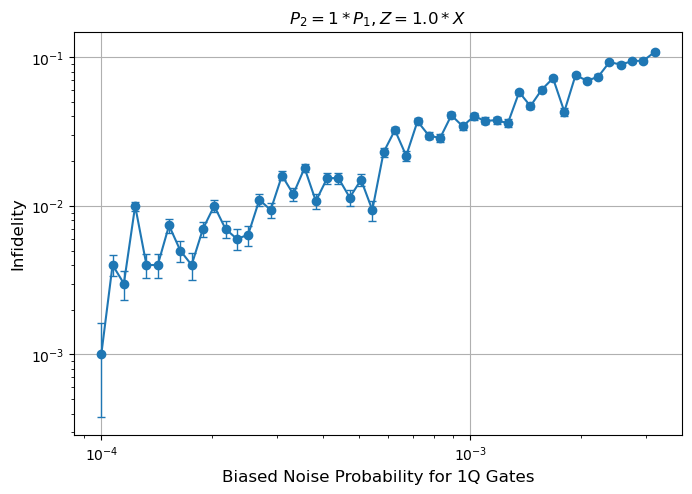

[0.000619775430297136, 0.0006420057118958271, 0.0006650331781779217, 0.0006888863966432237, 0.0007135949563141068, 0.00073918950401682, 0.0007657017819238015, 0.0007931646663977171, 0.0008216122081789037, 0.0008510796739588235, 0.0008816035893830402, 0.0009132217835281077, 0.0009459734348975704, 0.0009798991189830424, 0.0010150408574370387, 0.0010514421689048383, 0.001089148121563176, 0.0011282053874139743, 0.0011686622983816026, 0.0012105689042622514, 0.0012539770325739861, 0.0012989403503557574, 0.0013455144279631733, 0.001393756804908059, 0.0014437270577877944, 0.001495486870348975, 0.0015491001057281713, 0.0016046328809102884, 0.001662153643442282, 0.00172173325043665, 0.0017834450498951703, 0.001847364964378611, 0.0019135715770426686, 0.001982146220053904, 0.002053173065391986, 0.002126739218035878, 0.002202934811521681, 0.0022818531058483448, 0.00236359058769444, 0.0024482470728941796, 0.0025359258111039115, 0.002626733592570883, 0.0027207808568941987, 0.0028181818036429273, 0.00

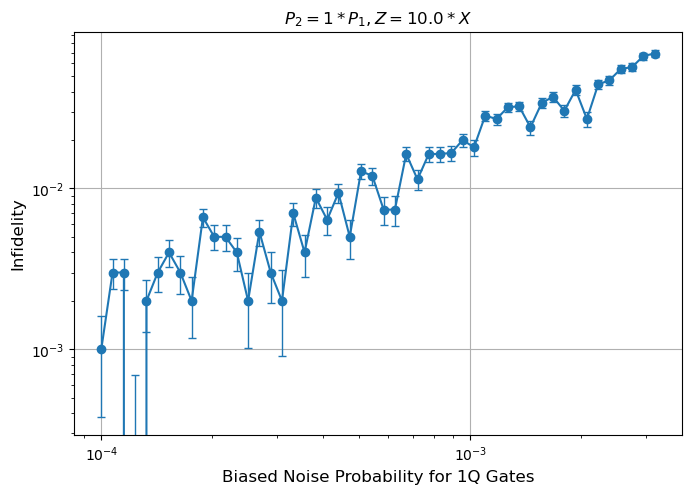

[0.000619775430297136, 0.0006420057118958271, 0.0006650331781779217, 0.0006888863966432237, 0.0007135949563141068, 0.00073918950401682, 0.0007657017819238015, 0.0007931646663977171, 0.0008216122081789037, 0.0008510796739588235, 0.0008816035893830402, 0.0009132217835281077, 0.0009459734348975704, 0.0009798991189830424, 0.0010150408574370387, 0.0010514421689048383, 0.001089148121563176, 0.0011282053874139743, 0.0011686622983816026, 0.0012105689042622514, 0.0012539770325739861, 0.0012989403503557574, 0.0013455144279631733, 0.001393756804908059, 0.0014437270577877944, 0.001495486870348975, 0.0015491001057281713, 0.0016046328809102884, 0.001662153643442282, 0.00172173325043665, 0.0017834450498951703, 0.001847364964378611, 0.0019135715770426686, 0.001982146220053904, 0.002053173065391986, 0.002126739218035878, 0.002202934811521681, 0.0022818531058483448, 0.00236359058769444, 0.0024482470728941796, 0.0025359258111039115, 0.002626733592570883, 0.0027207808568941987, 0.0028181818036429273, 0.00

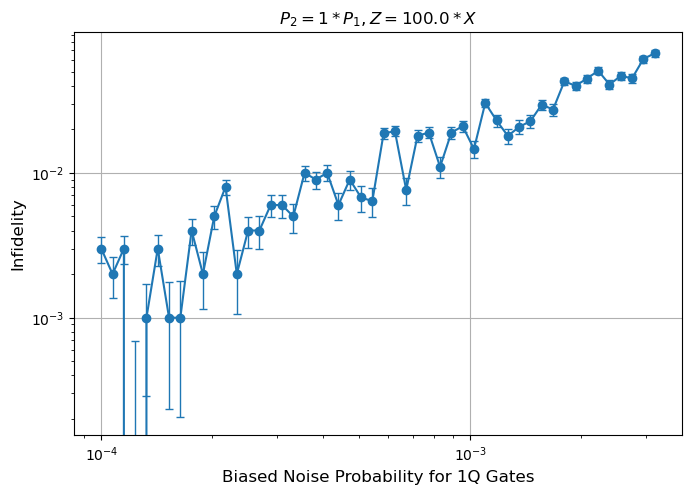

[0.000619775430297136, 0.0006420057118958271, 0.0006650331781779217, 0.0006888863966432237, 0.0007135949563141068, 0.00073918950401682, 0.0007657017819238015, 0.0007931646663977171, 0.0008216122081789037, 0.0008510796739588235, 0.0008816035893830402, 0.0009132217835281077, 0.0009459734348975704, 0.0009798991189830424, 0.0010150408574370387, 0.0010514421689048383, 0.001089148121563176, 0.0011282053874139743, 0.0011686622983816026, 0.0012105689042622514, 0.0012539770325739861, 0.0012989403503557574, 0.0013455144279631733, 0.001393756804908059, 0.0014437270577877944, 0.001495486870348975, 0.0015491001057281713, 0.0016046328809102884, 0.001662153643442282, 0.00172173325043665, 0.0017834450498951703, 0.001847364964378611, 0.0019135715770426686, 0.001982146220053904, 0.002053173065391986, 0.002126739218035878, 0.002202934811521681, 0.0022818531058483448, 0.00236359058769444, 0.0024482470728941796, 0.0025359258111039115, 0.002626733592570883, 0.0027207808568941987, 0.0028181818036429273, 0.00

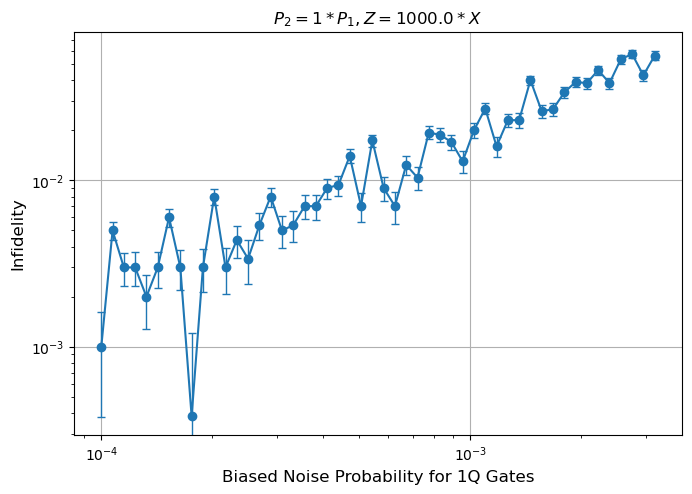

[0.000619775430297136, 0.0006420057118958271, 0.0006650331781779217, 0.0006888863966432237, 0.0007135949563141068, 0.00073918950401682, 0.0007657017819238015, 0.0007931646663977171, 0.0008216122081789037, 0.0008510796739588235, 0.0008816035893830402, 0.0009132217835281077, 0.0009459734348975704, 0.0009798991189830424, 0.0010150408574370387, 0.0010514421689048383, 0.001089148121563176, 0.0011282053874139743, 0.0011686622983816026, 0.0012105689042622514, 0.0012539770325739861, 0.0012989403503557574, 0.0013455144279631733, 0.001393756804908059, 0.0014437270577877944, 0.001495486870348975, 0.0015491001057281713, 0.0016046328809102884, 0.001662153643442282, 0.00172173325043665, 0.0017834450498951703, 0.001847364964378611, 0.0019135715770426686, 0.001982146220053904, 0.002053173065391986, 0.002126739218035878, 0.002202934811521681, 0.0022818531058483448, 0.00236359058769444, 0.0024482470728941796, 0.0025359258111039115, 0.002626733592570883, 0.0027207808568941987, 0.0028181818036429273, 0.00

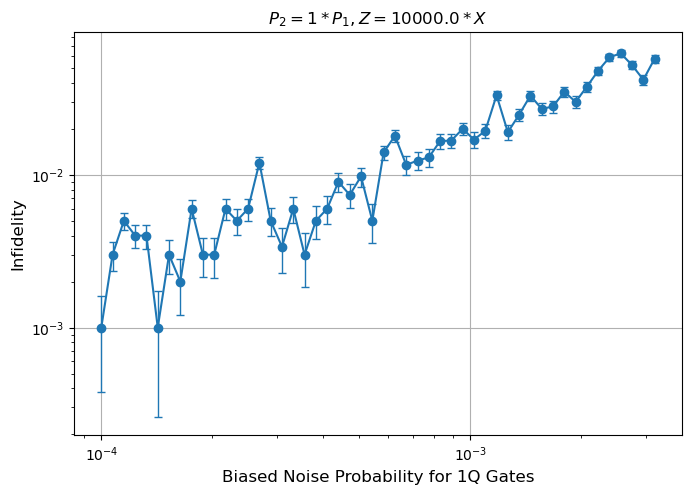

[0.000619775430297136, 0.0006420057118958271, 0.0006650331781779217, 0.0006888863966432237, 0.0007135949563141068, 0.00073918950401682, 0.0007657017819238015, 0.0007931646663977171, 0.0008216122081789037, 0.0008510796739588235, 0.0008816035893830402, 0.0009132217835281077, 0.0009459734348975704, 0.0009798991189830424, 0.0010150408574370387, 0.0010514421689048383, 0.001089148121563176, 0.0011282053874139743, 0.0011686622983816026, 0.0012105689042622514, 0.0012539770325739861, 0.0012989403503557574, 0.0013455144279631733, 0.001393756804908059, 0.0014437270577877944, 0.001495486870348975, 0.0015491001057281713, 0.0016046328809102884, 0.001662153643442282, 0.00172173325043665, 0.0017834450498951703, 0.001847364964378611, 0.0019135715770426686, 0.001982146220053904, 0.002053173065391986, 0.002126739218035878, 0.002202934811521681, 0.0022818531058483448, 0.00236359058769444, 0.0024482470728941796, 0.0025359258111039115, 0.002626733592570883, 0.0027207808568941987, 0.0028181818036429273, 0.00

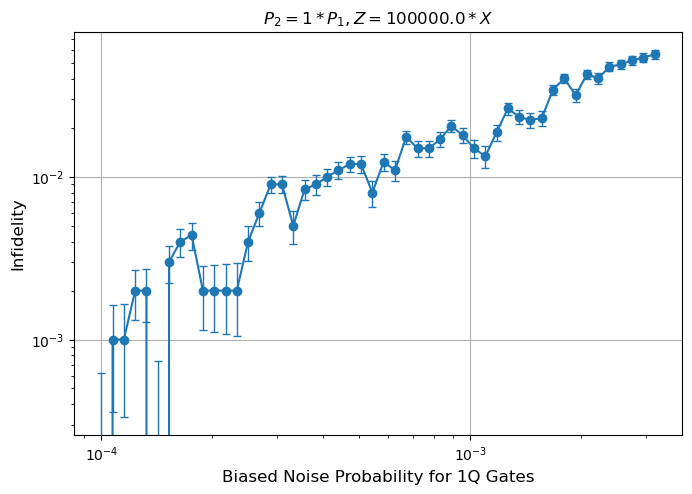

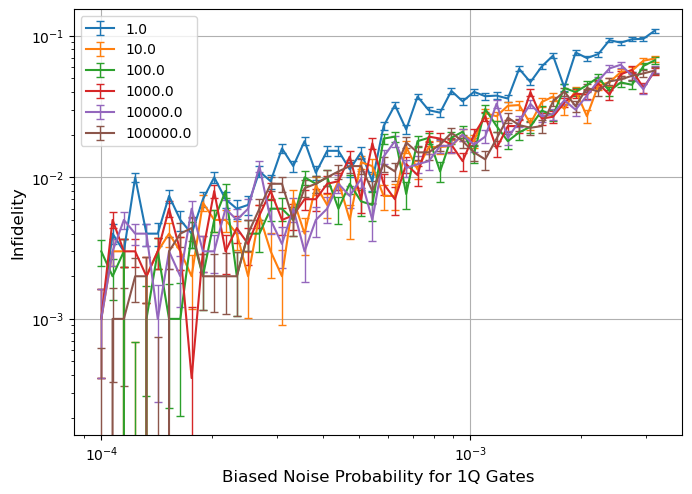

In [ ]:
factor = 1
bias_list_size = 6
bias_list = np.logspace(0,5, bias_list_size)
err_list_size = 50
error_list = np.logspace((-4), (-2.5), err_list_size)
pauli_prob_list = []
fid_list = []
unc_list = []
label_list= []


for bi in bias_list:
    pauli_prob, fid, unc =  explore_phase_bias_noise_3(factor, bi, err_list_size, error_list, shots = 10**(5))
    pauli_prob_list.append(pauli_prob)
    fid_list.append(fid)
    unc_list.append(unc)
    label_list.append(bi)


plt.figure(figsize=(7, 5))
for i in range(bias_list_size):
    plt.errorbar(
        pauli_prob_list[i],
        fid_list[i],
        yerr=unc_list[i],
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1,
        label = label_list[i]
    )
plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()




## Biased Noise + Idling time

model idling time erasure errors as mixed I/2 states between gates (during id gates)

In [ ]:
def explore_phase_bias_and_idle(factor, bias, err_list_size, error_list, shots = 1000):
    noise_list = []

    for p in error_list:
        # New noise model for each
        noise_model = NoiseModel()

        phase_p = (p *bias)/(1+bias)
        bitflip_p = (p )/(1+bias)
        identity_p = 1 - phase_p - bitflip_p
        p_sum = phase_p + bitflip_p + identity_p
        
        phase_p /= p_sum
        bitflip_p /= p_sum
        identity_p /= p_sum
        
        # Assign 1q and 2q Pauli errors
        noise_1q = [
            (Pauli('I'),    identity_p ),
            (Pauli('X'),    bitflip_p),
            (Pauli('Z'),    phase_p),
        ]
        
        two_qubit_paulis = []
        for P1 in ['I','X','Z']:
            for P2 in ['I','X','Z']:
                two_qubit_paulis.append((Pauli(P1+P2), None))

        # unsure what to do here

        p2 = factor*(p *bias)/(1+bias)
        p3 = factor*(p )/(1+bias)
        p4 = 1 - p2 - p3
        
        p_sum_2 = p2+p3+p4

        p2 /= p_sum_2
        p3 /= p_sum_2
        p4 /= p_sum_2

        noise_2q = []
        for pauli, _ in two_qubit_paulis:
            if pauli.to_label() == 'II':
                prob = p4
            else:
                prob = (1 - p4)/8
            noise_2q.append((pauli, prob))


        idle_noise = [ (Pauli('I')/2,    10**4 )],

        

        # Apply depolarizing error with probability p
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
        noise_model.add_all_qubit_quantum_error(pauli_error(idle_noise), ['id'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 


        # # Readout error 
        # readout_err = ReadoutError([[1-p2, p2],  
        #                         [p2, 1-p2]]) 
        # for i in range(0,7):
        #     noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)

    pauli_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in pauli_probs]

    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)

    plt.figure(figsize=(7, 5))
    plt.errorbar(
        pauli_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Biased Noise Probability for 1Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1, Z = {bias} * X$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

    return  pauli_probs,  fidelities, unc

        

# 2Q Depolarizing Noise

In [ ]:
def explore_depol_2Q(factor, err_list_size, error_list, shots = 1000):
    noise_list = []

    for error in error_list:
        # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
        #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

        noise_model = NoiseModel()

        error2 = error*factor

        noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error,2),['cz'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error,2),['cx'])

        readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                                [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
        
        for i in range(0,7):
            noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)


    depol_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in depol_probs]


    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)


    plt.figure(figsize=(7, 5))
    plt.errorbar(
        depol_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Depolarizing Noise Probability for 2Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

        

## p*11

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


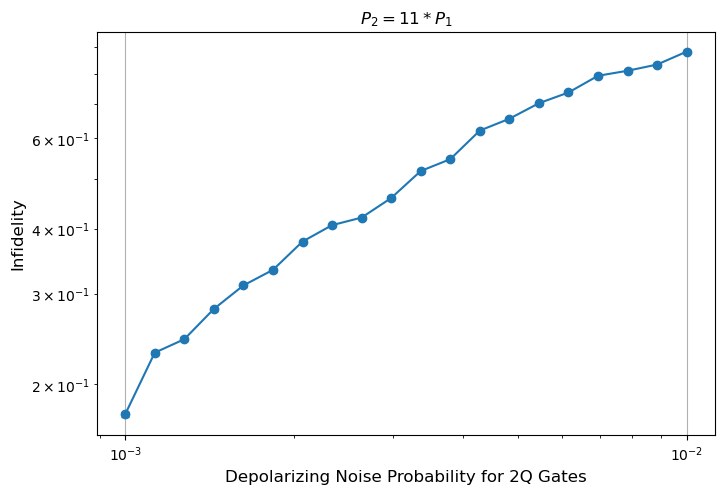

In [ ]:
factor = 11
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol_2Q(factor, err_list_size, error_list, shots = 10**(5))

## p*14

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


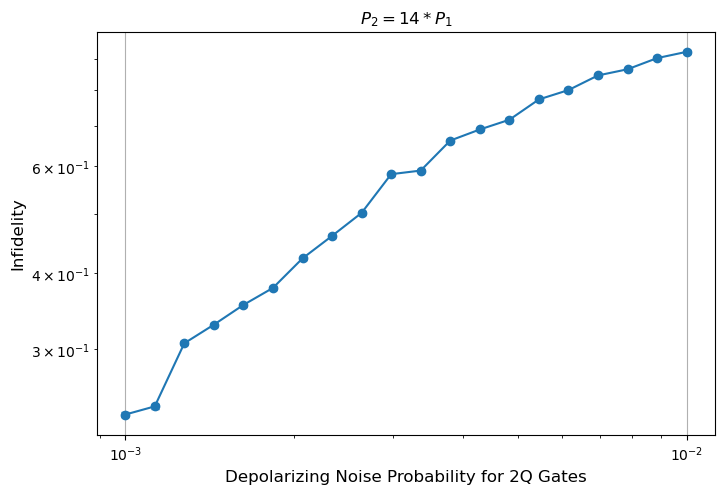

In [ ]:
factor = 14
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol_2Q(factor, err_list_size, error_list, shots = 10**(5))

# H only Depolarizing Noise 

In [ ]:
def explore_depol_h(factor, err_list_size, error_list, shots = 1000):
    noise_list = []

    for error in error_list:
        # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
        #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

        noise_model = NoiseModel()

        error2 = error*factor

        noise_model.add_all_qubit_quantum_error(depolarizing_error(0,1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(0,2),['cz'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(0,2),['cx'])

        readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                                [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
        
        for i in range(0,7):
            noise_model.add_readout_error(readout_err, [i])
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)


    depol_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in depol_probs]


    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)


    plt.figure(figsize=(7, 5))
    plt.errorbar(
        depol_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Depolarizing Noise Probability for H Gate Only", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

        

## p*11

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


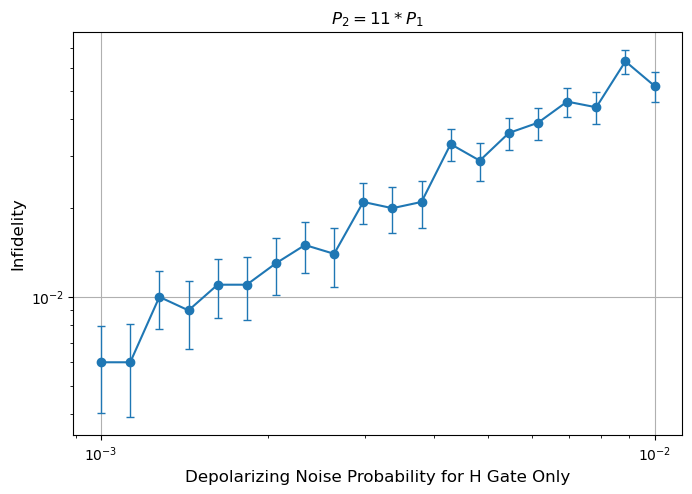

In [ ]:
factor = 11
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol_h(factor, err_list_size, error_list, shots = 10**(5))

## p*14

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


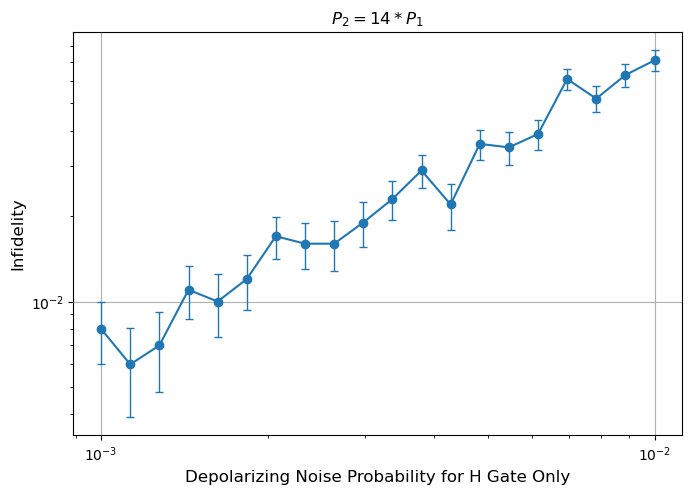

In [ ]:
factor = 14
err_list_size = 20
error_list = np.logspace((-3), (-2), err_list_size)


explore_depol_h(factor, err_list_size, error_list, shots = 10**(5))

# 1Q Pauli Noise

In [101]:
def explore_pauli(factor, err_list_size, error_list, shots = 1000):
    noise_list = []

    for p in error_list:
        # New noise model for each
        noise_model = NoiseModel()
        
        # Assign 1q and 2q Pauli errors
        noise_1q = [
            (Pauli('I'),    1-p), 
            (Pauli('X'),    2*p/5),
            (Pauli('Y'),    p/5),
            (Pauli('Z'),    2*p/5),
        ]
        
        two_qubit_paulis = []
        for P1 in ['I','X','Y','Z']:
            for P2 in ['I','X','Y','Z']:
                two_qubit_paulis.append((Pauli(P1+P2), None))

        p2 = factor*p
        noise_2q = []
        for pauli, _ in two_qubit_paulis:
            if pauli.to_label() == 'II':
                prob = 1 - p2
            else:
                prob = p2/15
            noise_2q.append((pauli, prob))
        

        # Apply depolarizing error with probability p
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
        noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

        # Readout error 
        readout_err = ReadoutError([[1-p2, p2],  
                                [p2, 1-p2]]) 
        for i in range(0,7):
            noise_model.add_readout_error(readout_err, [i])
            
        
        noise_list.append(noise_model)
    
    fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = shots)

    sample_err_rate = get_sample_error_rate(fid_dict)


    pauli_probs = sorted(error_list)
    fidelities = [1 - fid_dict[p] for p in pauli_probs]


    # Uncertainty Calculations
    unc = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate]

    print(unc)


    plt.figure(figsize=(7, 5))
    plt.errorbar(
        pauli_probs,
        fidelities,
        yerr=unc,
        fmt='o-',           # circle marker and solid line
        capsize=3,          # length of the little “T” caps on each bar
        elinewidth=1,       # width of the error‐bar lines
        markeredgewidth=1
    )
    plt.xlabel("Depolarizing Noise Probability for 1Q Gates", fontsize=12)
    plt.ylabel("Infidelity", fontsize=12)
    plt.title(f"$P_2 = {factor} * P_1$")
    plt.grid(True)
    plt.tight_layout()
    plt.yscale('log')
    plt.xscale('log')
    plt.show()

        

## 2*p

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


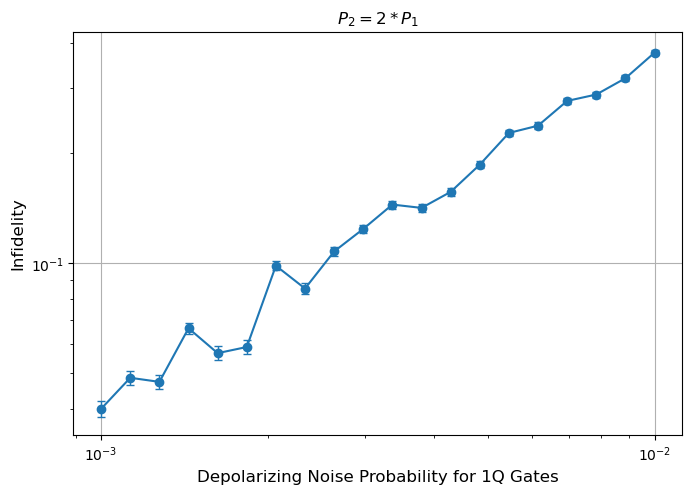

In [146]:
factor = 2
err_list_size = 20
error_list = np.logspace(-3, -2, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


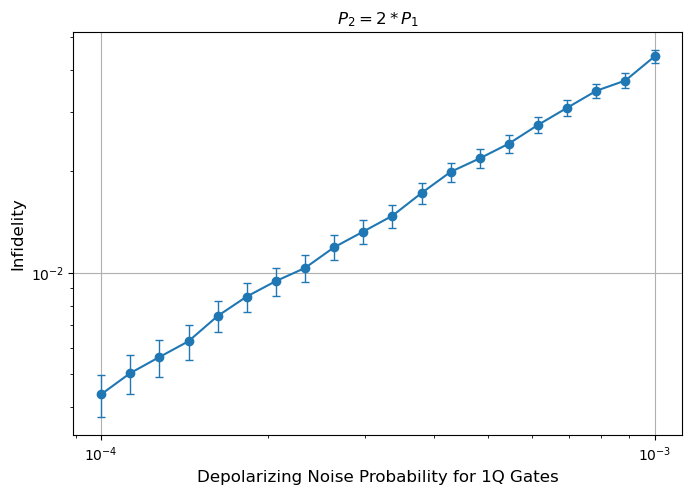

In [102]:
factor = 2
err_list_size = 20
error_list = np.logspace(-4, -3, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

## 3*p

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


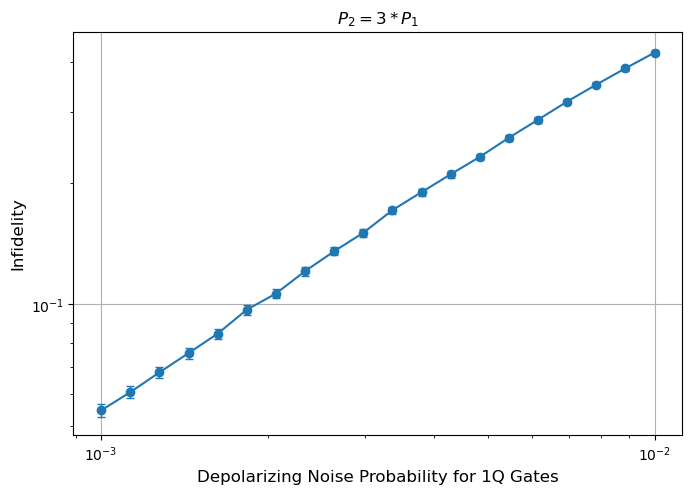

In [103]:
factor = 3
err_list_size = 20
error_list = np.logspace(-3, -2, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


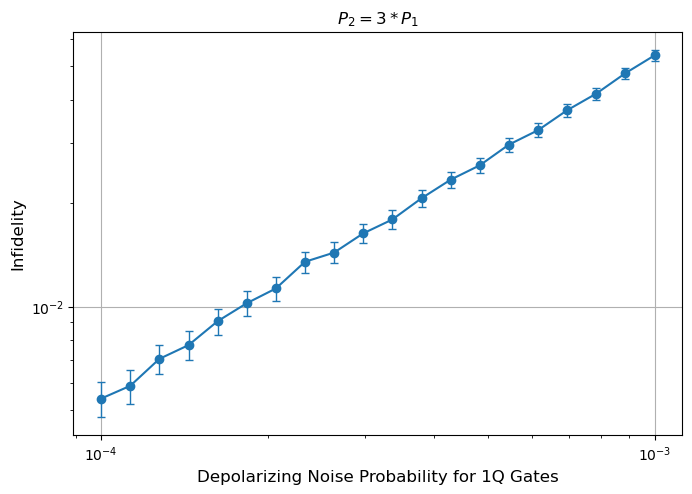

In [104]:
factor = 3
err_list_size = 20
error_list = np.logspace(-4, -3, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

## 5*p

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


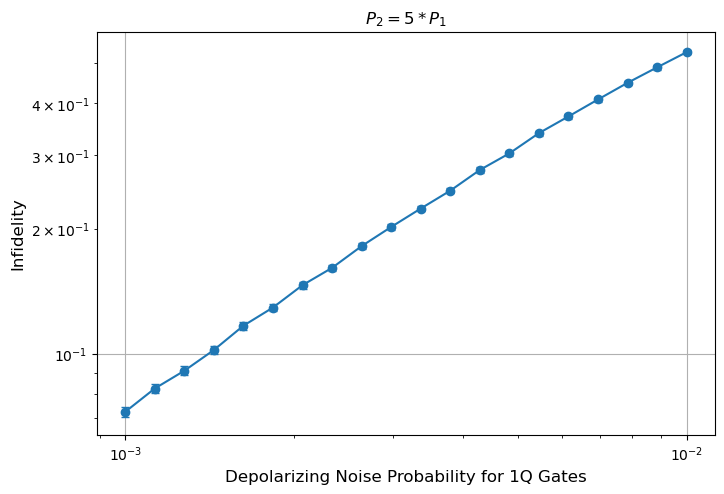

In [105]:
factor = 5
err_list_size = 20
error_list = np.logspace(-3, -2, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


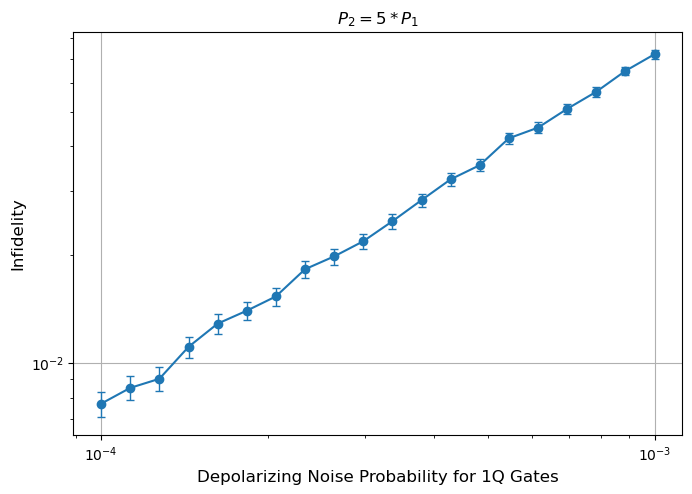

In [106]:
factor = 5
err_list_size = 20
error_list = np.logspace(-4, -3, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

## 15*p

[0.0019590197548774234, 0.002081261249798022, 0.0022111121374448406, 0.002349042419794388, 0.0024955503928341793, 0.0026511642010266538, 0.002816443446239895, 0.0029919808459856947, 0.003178403933754265, 0.0033763767917029757, 0.0035866018028407917, 0.0038098214060252942, 0.004046819832403352, 0.00429842479619461, 0.004565509105713762, 0.0048489921519781105, 0.005149841221815697, 0.005469072569664676, 0.005807752166732281, 0.006166996027240491]


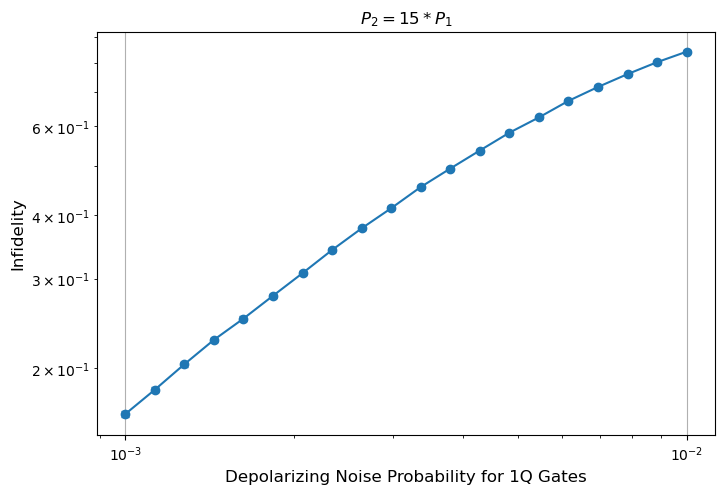

In [107]:
factor = 15
err_list_size = 20
error_list = np.logspace(-3, -2, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

[0.000619775430297136, 0.0006584872146987666, 0.000699616394533821, 0.0007433138106318652, 0.0007897396929025496, 0.0008390642401473815, 0.0008914682347541211, 0.0009471436941861292, 0.0010062945612452027, 0.001069137435146148, 0.0011359023454920356, 0.0012068335712775878, 0.001282190507070681, 0.0013622485785238165, 0.0014473002093428585, 0.0015376558417824115, 0.001633645012637466, 0.001735617486548963, 0.0018439444482243141, 0.0019590197548774234]


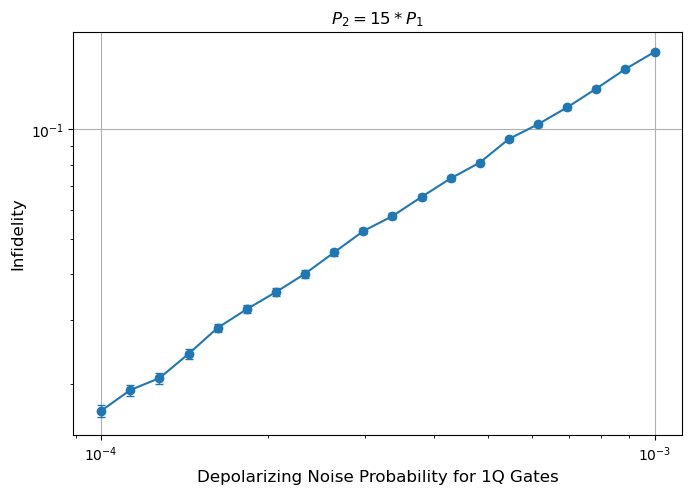

In [108]:
factor = 15
err_list_size = 20
error_list = np.logspace(-4, -3, err_list_size)

explore_pauli(factor, err_list_size, error_list, shots = 10**(5))

# scratchwork

In [16]:
err_list_size = 30
reps = 50
error_list = np.linspace(10**(-5), 10**(-1), err_list_size)
noise_list = []

for error in error_list:
    readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
                                [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

    noise_model = NoiseModel()

    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,2),['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,2),['cx'])
    
    noise_list.append(noise_model)

In [17]:

fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(
c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


1.0000000000000013
1.0000000000000013
0.0
1.645901843446476e-96
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
9.269025206451845e-33
1.0000000000000013
1.0000000000000013
3.171318042792612e-67
2.08585003775695e-66
9.849983963230732e-68
1.2952992591737474e-67
4.747009150971459e-68
1.0000000000000013
3.5446510324698294e-35
2.114069478915696e-96
4.2367245922510304e-69
2.996272867003007e-95
1.49975978266186e-32
4.149848861553851e-36
2.100597774592758e-66
2.041084752394e-32
9.495567745759799e-66
9.569033395205371e-67
1.0000000000000013
1.645901843446476e-96
9.279834490796581e-67
1.0000000000000013
1.0000000000000013
1.0000000000000013
4.040610940368063e-66
1.0000000000000013
0.6180339887498956
6.515725970549387e-67
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.579700791586406e-32
4.737040819060664e-63
1.0000000000000013
3.301770465009881e-66
1.0000000000000013
1.49975978266186e-32
0.0
1.49975978266186e-32
2.3738919364399497e-66
1.

KeyboardInterrupt: 

In [ ]:
fid_theta_7_sv_df.to_csv('fid_theta_7_sv_df')
fid_theta_8_sv_df.to_csv('fid_theta_8_sv_df')

In [21]:
from lmfit import Model
from pandas import DataFrame

In [ ]:
def decay(x, a, r, b):
    y = a * np.exp(-x * r) + b
    return y

In [ ]:
fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)

fid_model = Model(decay)
#print(f'independent variables: {decay_model.independent_vars}')


params = fid_model.make_params()

result_7 = fid_model.fit(fid_theta_7_sv_df['mean'], x=np.array(list(error_list)), a = 1, b = 0, r = 5)
result_8 = fid_model.fit(fid_theta_8_sv_df['mean'], x=np.array(list(error_list)), a = 1, b = 0, r = 5)

print(result_7.fit_report())
print(result_8.fit_report())

#plt.plot(error_list, result_7.init_fit, '--', label='initial fit')
plt.plot(error_list, result_7.best_fit, '--', label='7 best fit', color = "blue")
plt.plot(error_list, result_8.best_fit, '--', label='7 best fit', color = "red")


plt.scatter(x = error_list, y=fid_theta_7_sv_df['mean'], label="7 qubit")
plt.scatter(x = error_list, y=fid_theta_8_sv_df['mean'], label="8 qubit")
plt.title("Fidelity of Logical Steane State vs. Depolarizing Noise Error")
plt.xlabel("Depolarizing Noise Error")
plt.ylabel("Fidelity of Steane State")
plt.legend()

plt.ylim(0,1.1)

In [ ]:
def get_sample_error_rate(fidelity, shots = 1000):
    sample_err_rate = []
    for fid in fidelity['mean']:
        # print(fid)
        sample_err_rate.append((fid)*(1 - fid) / shots)
    
    return sample_err_rate
    


In [ ]:
# use plt error barrs
# use more shots 
#  about benchmarking logical gates for steane code
# error map for 1 and 2 qubit 
# have numbers for errors of each gate (H, CZ, meas)
# find way to measure effective logical error rate that isn't repeating QEC enc rounds



sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]


print(fidelities_7)

# Uncertainty Calculations
unc_7 = [1.96 * np.sqrt(i) for i in sample_err_rate_7]



plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities_7,
    yerr=unc_7,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

### p*11


In [76]:

err_list_size = 15
reps = 50
error_list = np.logspace((-3), (-2), err_list_size)
noise_list = []

for error in error_list:
    # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
    #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

    noise_model = NoiseModel()

    error2 = error*11

    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cx'])

    readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                            [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
    
    for i in range(0,7):
        noise_model.add_readout_error(readout_err, [i])

    
    noise_list.append(noise_model)

In [69]:

fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


1.0000000000000013
1
1.0000000000000013
2
1.0000000000000013
3
1.0000000000000013
4


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [73]:
p_11_fid_dict = fidelity_sweep(noise_list, error_list, err_list_size, shots = 1000)

In [74]:
print(p_11_fid_dict)

{0.001: 0.8818541019662511, 0.0011787686347935879: 0.8693819660112515, 0.0013894954943731374: 0.8310901699437508, 0.0016378937069540646: 0.8248541019662511, 0.0019306977288832496: 0.7876180339887511, 0.0022758459260747888: 0.7413262379212505, 0.0026826957952797246: 0.7181803398875001, 0.0031622776601683794: 0.6732360679775009, 0.003727593720314938: 0.6149442719100001, 0.004393970560760791: 0.5449442719099999, 0.005179474679231213: 0.5137639320225009, 0.006105402296585327: 0.4420344418537493, 0.0071968567300115215: 0.40732623792124983, 0.008483428982440717: 0.3099442719099996, 0.01: 0.26038196601125047}


[0.0019590197548774234, 0.002126739218035879, 0.002308780830392648, 0.002506357241190407, 0.0027207808568941987, 0.00295347121869863, 0.0032059626826169666, 0.003479912335002542, 0.0037771080441324455, 0.004099476505880461, 0.004449091085386222, 0.0048281791829014155, 0.005239128755311795, 0.005684493498175905, 0.006166996027240491]


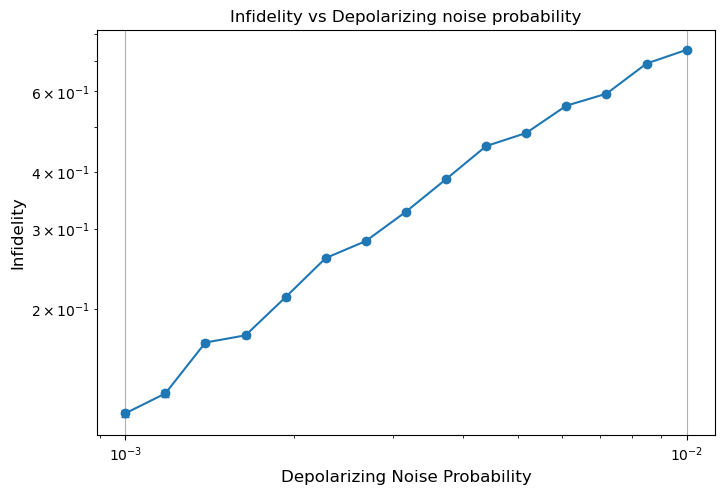

In [81]:
p_11_sample_err_rate = get_sample_error_rate(p_11_fid_dict)


depol_probs = sorted(error_list)
fidelities = [1 - p_11_fid_dict[p] for p in depol_probs]


# Uncertainty Calculations
unc = [1.96 * np.sqrt(abs(i)) for i in p_11_sample_err_rate]

print(unc)


plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities,
    yerr=unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()


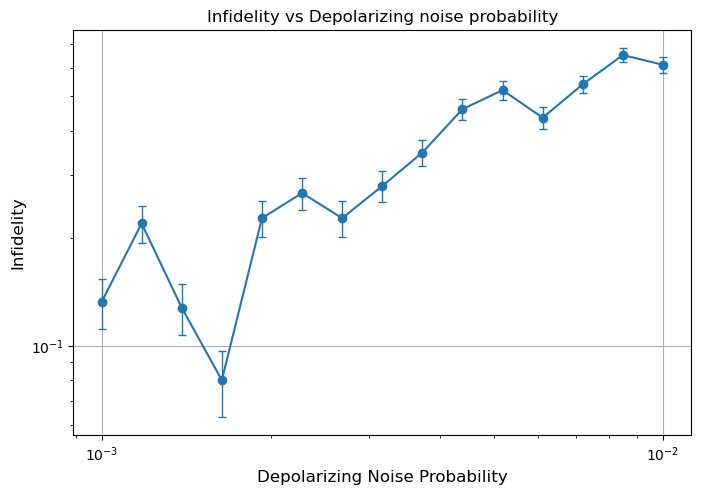

In [45]:

fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]


#print(fidelities_7)

# Uncertainty Calculations
unc_7 = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate_7]
# [print(i) for i in sample_err_rate_7]


plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities_7,
    yerr=unc_7,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

p * 12

In [66]:
err_list_size = 15
reps = 50
error_list = np.logspace((-3), (-2), err_list_size)
noise_list = []

for error in error_list:
    # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
    #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

    noise_model = NoiseModel()

    error2 = error * 12

    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cx'])

    readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                            [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
    
    for i in range(0,7):
        noise_model.add_readout_error(readout_err, [i])

    
    noise_list.append(noise_model)

In [67]:

fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
3.5446510324698294e-35
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.106288833869253e-65
9.269025206451845e-33
1.0000000000000013
1.0000000000000013
5.247839359203893e-32
1.0000000000000013
1.0000000000000013
2.7082966901915313e-66
1.0000000000000013
0.6180339887498956
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
7.476605632960952e-69
1.0000000000000013
1.0000000000000013
2.9339282580375996e-65
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.8726705418768793e-96
1.1447007535292892e-71
9.71453298192309e-66
1.0000000000000013
2.041084752394e-32
9.495567745759799e-66
1.5010011319609632e-32
1.0000000000000013
3.0907306894537255e-67
1.0000000000000013
1.0000000000000013
1.49975978266186e-32
1.0000000000000013
1.9234685566231086e-66

KeyboardInterrupt: 

In [ ]:

fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]


#print(fidelities_7)

# Uncertainty Calculations
unc_7 = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate_7]
# [print(i) for i in sample_err_rate_7]


plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities_7,
    yerr=unc_7,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

## p*13

In [ ]:

err_list_size = 15
reps = 50
error_list = np.logspace((-3), (-2), err_list_size)
noise_list = []

for error in error_list:
    # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
    #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

    noise_model = NoiseModel()

    error2 = error*13

    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cx'])

    readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                            [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
    
    for i in range(0,7):
        noise_model.add_readout_error(readout_err, [i])

    
    noise_list.append(noise_model)

In [ ]:
fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

In [ ]:

fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]


#print(fidelities_7)

# Uncertainty Calculations
unc_7 = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate_7]
# [print(i) for i in sample_err_rate_7]


plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities_7,
    yerr=unc_7,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

## p*14

In [ ]:

err_list_size = 15
reps = 50
error_list = np.logspace((-3), (-2), err_list_size)
noise_list = []

for error in error_list:
    # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
    #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

    noise_model = NoiseModel()

    error2 = error*14

    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cx'])

    readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                            [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
    
    for i in range(0,7):
        noise_model.add_readout_error(readout_err, [i])

    
    noise_list.append(noise_model)

In [ ]:
fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

In [ ]:

fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]


#print(fidelities_7)

# Uncertainty Calculations
unc_7 = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate_7]
# [print(i) for i in sample_err_rate_7]


plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities_7,
    yerr=unc_7,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

## p*15

In [ ]:

err_list_size = 15
reps = 50
error_list = np.logspace((-3), (-2), err_list_size)
noise_list = []

for error in error_list:
    # readout_err = ReadoutError([[0.98, 0.02],  # P(measured 0 | actual 0), P(1 | 0)
    #                             [0.02, 0.98]]) # P(0 | 1), P(1 | 1)

    noise_model = NoiseModel()

    error2 = error*15

    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cz'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error2,2),['cx'])

    readout_err = ReadoutError([[1-error2, error2],  # P(measured 0 | actual 0), P(1 | 0)
                            [error2, 1-error2]]) # P(0 | 1), P(1 | 1)
    
    for i in range(0,7):
        noise_model.add_readout_error(readout_err, [i])

    
    noise_list.append(noise_model)

In [ ]:
fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

In [ ]:

fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]


#print(fidelities_7)

# Uncertainty Calculations
unc_7 = [1.96 * np.sqrt(abs(i)) for i in sample_err_rate_7]
# [print(i) for i in sample_err_rate_7]


plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities_7,
    yerr=unc_7,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("Depolarizing Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title("Infidelity vs Depolarizing noise probability")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

## vary pauli error

In [22]:
from qiskit.quantum_info import Pauli
from qiskit_aer.noise import pauli_error 

In [ ]:
[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2] 

## 2* p (small errors)

In [38]:

noise_list = []
err_list_size = 15
pauli_probs = np.logspace(-3,-2, err_list_size)
for p in pauli_probs:
    # New noise model for each depolarizing probability
    noise_model = NoiseModel()
    
    # Assign 1q and 2q Pauli errors
    noise_1q = [
        (Pauli('I'),    1-p), 
        (Pauli('X'),    2*p/5),
        (Pauli('Y'),    p/5),
        (Pauli('Z'),    2*p/5),
    ]
    
    two_qubit_paulis = []
    for P1 in ['I','X','Y','Z']:
        for P2 in ['I','X','Y','Z']:
            two_qubit_paulis.append((Pauli(P1+P2), None))

    p2 = 2*p
    noise_2q = []
    for pauli, _ in two_qubit_paulis:
        if pauli.to_label() == 'II':
            prob = 1 - p2
        else:
            prob = p2/15
        noise_2q.append((pauli, prob))
    
    

    # Apply depolarizing error with probability p
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

    # Keep readout error constant
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    noise_list.append(noise_model)

In [39]:
fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


1.0000000000000013
1
9.849983963230543e-68
2
1.0000000000000013
3
1.0000000000000013
4
1.0000000000000013
5
1.0000000000000013
6
1.0000000000000013
7
1.0000000000000013
8
1.0000000000000013
9
1.0000000000000013
10
1.0000000000000013
11
4.747009150971463e-68
12
1.0000000000000013
13
1.0000000000000013
14
0.0
15


ValueError: Length of values (15) does not match length of index (30)

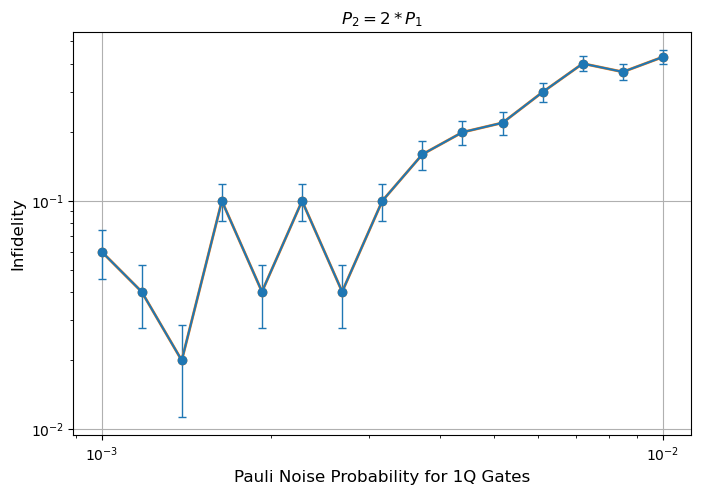

In [60]:
fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]

pauli_probs = sorted(fidelity_results_7.keys())
fidelities = [1 - fidelity_results_7[p] for p in pauli_probs]

unc = [1.96 * np.sqrt(i) for i in sample_err_rate_7]

plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities,
    yerr=unc,
    fmt='o-',           
    capsize=3,          
    elinewidth=1,       
    markeredgewidth=1
)
plt.plot(pauli_probs, fidelities, marker='o', linewidth=2)
plt.xlabel("Pauli Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title(f"$P_2 = 2 * P_1$")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

## 3 * p (small errors)

In [61]:
pauli_probs = np.logspace(-3,-2, 15)
noise_list = []
for p in pauli_probs:
    # New noise model for each depolarizing probability
    noise_model = NoiseModel()
    
    # Assign 1q and 2q Pauli errors
    noise_1q = [
        (Pauli('I'),    1-p), 
        (Pauli('X'),    2*p/5),
        (Pauli('Y'),    p/5),
        (Pauli('Z'),    2*p/5),
    ]
    
    two_qubit_paulis = []
    for P1 in ['I','X','Y','Z']:
        for P2 in ['I','X','Y','Z']:
            two_qubit_paulis.append((Pauli(P1+P2), None))

    p2 = 3*p
    noise_2q = []
    for pauli, _ in two_qubit_paulis:
        if pauli.to_label() == 'II':
            prob = 1 - p2
        else:
            prob = p2/15
        noise_2q.append((pauli, prob))
    
    

    # Apply depolarizing error with probability p
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

    # Keep readout error constant
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    noise_list.append(noise_model)

In [62]:
fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.579700791586406e-32
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
3.171318042792612e-67
1.579700791586406e-32
1.0000000000000013
1.106288833869253e-65
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.645901843446476e-96
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.49975978266186e-32
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
7.490682167507517e-96
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.6270555071183654e-67
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.0000000000000013
1.00000

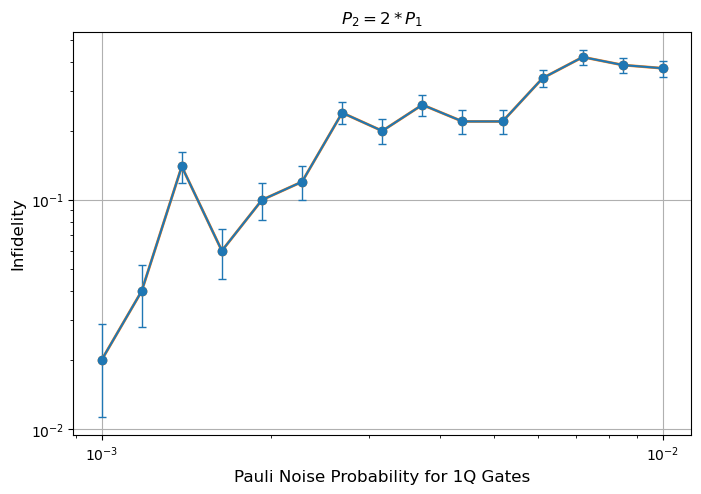

In [63]:
fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]

pauli_probs = sorted(fidelity_results_7.keys())
fidelities = [1 - fidelity_results_7[p] for p in pauli_probs]

unc = [1.96 * np.sqrt(i) for i in sample_err_rate_7]

plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities,
    yerr=unc,
    fmt='o-',           
    capsize=3,          
    elinewidth=1,       
    markeredgewidth=1
)
plt.plot(pauli_probs, fidelities, marker='o', linewidth=2)
plt.xlabel("Pauli Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title(f"$P_2 = 2 * P_1$")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()

## 2*q

In [ ]:
pauli_probs = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2] 

In [28]:
pauli_probs = np.logspace(-4,-2,10)
noise_list = []
for p in pauli_probs:
    # New noise model for each depolarizing probability
    noise_model = NoiseModel()
    
    # Assign 1q and 2q Pauli errors
    noise_1q = [
        (Pauli('I'),    1-p), 
        (Pauli('X'),    2*p/5),
        (Pauli('Y'),    p/5),
        (Pauli('Z'),    2*p/5),
    ]
    
    two_qubit_paulis = []
    for P1 in ['I','X','Y','Z']:
        for P2 in ['I','X','Y','Z']:
            two_qubit_paulis.append((Pauli(P1+P2), None))

    p2 = 2*p
    noise_2q = []
    for pauli, _ in two_qubit_paulis:
        if pauli.to_label() == 'II':
            prob = 1 - p2
        else:
            prob = p2/15
        noise_2q.append((pauli, prob))
    
    

    # Apply depolarizing error with probability p
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['id'])
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_1q), ['h'])
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cz']) 
    noise_model.add_all_qubit_quantum_error(pauli_error(noise_2q), ['cx']) 

    # Keep readout error constant
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    noise_list.append(noise_model)

In [29]:
fid_theta_7_sv_df, fid_theta_8_sv_df = explore_error(reps, noise_list,  error_list, err_list_size, shots = 10**(3))

c:\Users\diyan\anaconda3\lib\site-packages\qiskit\circuit\quantumcircuit.py:3263: RuntimeWarning: Cregbundle set to False since an instruction needs to refer to individual classical wire
  return circuit_drawer(


1.0000000000000013
1
1.0000000000000013
2
1.0000000000000013
3
1.0000000000000013
4
1.0000000000000013
5
1.0000000000000013
6
1.0000000000000013
7
1.0000000000000013
8
1.0000000000000013
9
3.171318042792615e-67
10


IndexError: list index out of range

In [ ]:
fid_theta_7_sv_df['mean'] = fid_theta_7_sv_df.mean(axis=1)
fid_theta_8_sv_df['mean'] = fid_theta_8_sv_df.mean(axis=1)


sample_err_rate_7 = get_sample_error_rate(fid_theta_7_sv_df)


fidelity_results_7 = fid_theta_7_sv_df['mean']


depol_probs = sorted(error_list)
fidelities_7 = [1 - fidelity_results_7.loc[p] for p in depol_probs]

pauli_probs = sorted(fidelity_results_7.keys())
fidelities = [1 - fidelity_results_7[p] for p in pauli_probs]

unc = [1.96 * np.sqrt(i) for i in sample_err_rate_7]

plt.figure(figsize=(7, 5))
plt.errorbar(
    depol_probs,
    fidelities,
    yerr=unc,
    fmt='o-',           
    capsize=3,          
    elinewidth=1,       
    markeredgewidth=1
)
plt.plot(pauli_probs, fidelities, marker='o', linewidth=2)
plt.xlabel("Pauli Noise Probability for 1Q Gates", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.title(f"$P_2 = 2 * P_1$")
plt.grid(True)
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.show()